[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/06_information_theory_in_deep_learning/first_principles.ipynb)

# Module 06 — Information Theory in Deep Learning

## 1. Why This Module Exists

A modern training script contains one number that everything else is tuned against: a loss in
nats. This module shows that the loss, the regularizer beside it, and the metric reported at the
end are three readings of the same information-theoretic quantity.

Two questions generate every objective here. *How many nats does this model need to describe the
data?* — that is cross-entropy, negative log-likelihood, description length, bits per byte.
*How many nats does this representation keep, and about what?* — that is mutual information, the
rate of a code, the KL term of a variational autoencoder, the InfoNCE score.

Modules [01](../01_self_information_and_entropy/) to
[05](../05_mutual_information/) built the vocabulary. What is new here is that the two questions
are not independent: they are the two axes of a single trade-off whose shape Shannon settled in
1959, and every objective below is a Lagrangian sitting somewhere on it.

The payoff is diagnostic. Once the ELBO is read as a point in a rate-distortion plane, posterior
collapse stops being a mysterious optimizer failure and becomes a statement about level sets;
once the RLHF penalty is read as a free energy, the reference policy stops being a guardrail and
becomes part of the optimum.

## 2. Intuition

Fix a data distribution and an encoder that turns a sample $x$ into a code $z$. Two numbers
describe what happened.

The **rate** $R$ is how many nats the code costs to transmit. The **distortion** $D$ is how many
nats it then costs to describe $x$ given $z$.

Both are non-negative, so every encoder is a point in the quarter-plane. Not every point is
reachable: describing $x$ in two instalments cannot beat describing it in one, so

$$
D + R \;\ge\; H(X).
$$

That single inequality draws a line of slope $-1$ across the plane and forbids everything below
it. The line is the whole subject.

The evidence lower bound is exactly $-(D + R)$, so the ELBO is **constant along the forbidden
line's boundary**. A variational autoencoder that reaches the optimum has told you the sum
$D + R$ and nothing about where on the line it landed — which is why the same optimal ELBO is
attained both by a code carrying the entire message and by a code carrying nothing at all.

Every objective in this module is a device for choosing a point on that line: the multiplier
$\beta$ in a $\beta$-VAE, the $\beta$ of the Information Bottleneck, the temperature of an RLHF
penalty, the Lagrange multiplier of a neural codec. They differ only in which axis they price.

The first code cell is the notebook preamble. It fixes the plotting defaults, seeds the single
random generator used everywhere below, defines the discrete information functionals that later
cells reuse, and prints the machine epsilon that every residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps


def entropy(p):
    """Shannon entropy of a discrete distribution, in nats."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0.0]
    return float(-(p * np.log(p)).sum())


def kl(p, q):
    """Kullback-Leibler divergence D(p || q) of two discrete distributions, in nats."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    m = p > 0.0
    if np.any(q[m] <= 0.0):
        return np.inf
    return float((p[m] * np.log(p[m] / q[m])).sum())


def mutual_information(joint):
    """Mutual information of a discrete joint distribution given as a 2-D array, in nats."""
    joint = np.asarray(joint, dtype=float)
    px, py = joint.sum(axis=1), joint.sum(axis=0)
    m = joint > 0.0
    return float((joint[m] * np.log(joint[m] / np.outer(px, py)[m])).sum())


print(f"machine epsilon = {EPS:.4e}")
print(f"one bit = {np.log(2):.6f} nats;  one nat = {1.0 / np.log(2):.6f} bits")

machine epsilon = 2.2204e-16
one bit = 0.693147 nats;  one nat = 1.442695 bits


Every residual reported later is quoted as a multiple of this number. All quantities in this
module are in **nats** unless a line says "bits" explicitly, following
[the notation register](../../docs/notation.md).

The next cell draws the picture described above for a one-bit source, $X$ uniform on
$\lbrace 0, 1 \rbrace$, so that $H(X) = \ln 2$ nats. It shades the region forbidden by
$D + R \ge H(X)$, marks the two corner solutions, and plots the two encoders computed by hand in
Example 6.3 — one whose prior matches the aggregate posterior and one whose prior does not.

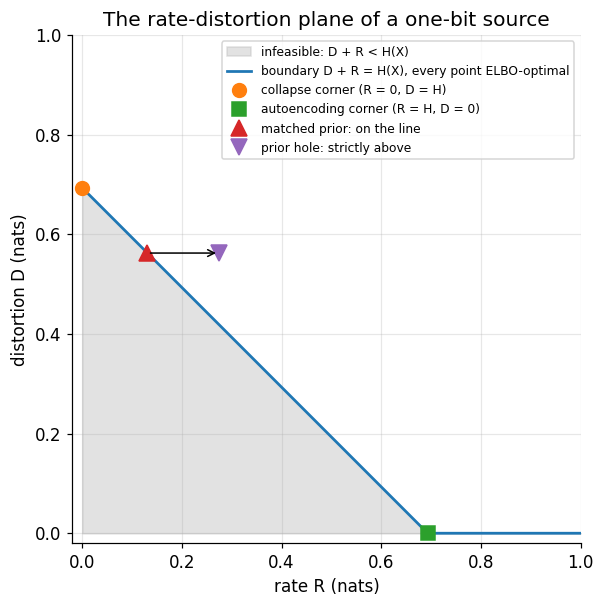

H(X)                          = 0.693147 nats
I(X;Z) of the flip-1/4 encoder = 0.130812 nats
D (optimal decoder)            = 0.562335 nats
matched prior:  R = 0.130812,  D + R = 0.693147
prior hole:     R = 0.274653,  D + R = 0.836988


In [2]:
H_source = np.log(2.0)

eps_flip = 0.25
q_z_given_x = np.array([[1 - eps_flip, eps_flip], [eps_flip, 1 - eps_flip]])
p_x = np.array([0.5, 0.5])
joint_xz = p_x[:, None] * q_z_given_x
I_xz = mutual_information(joint_xz)
D_opt = H_source - I_xz

prior_matched = p_x @ q_z_given_x
prior_hole = np.array([0.75, 0.25])
R_matched = float(sum(p_x[i] * kl(q_z_given_x[i], prior_matched) for i in range(2)))
R_hole = float(sum(p_x[i] * kl(q_z_given_x[i], prior_hole) for i in range(2)))

fig, ax = plt.subplots(figsize=(6.0, 6.0))
r_grid = np.linspace(0.0, 1.0, 200)
ax.fill_between(r_grid, 0.0, np.clip(H_source - r_grid, 0.0, None),
                color="0.75", alpha=0.45, label="infeasible: D + R < H(X)")
ax.plot(r_grid, np.clip(H_source - r_grid, 0.0, None), lw=1.8,
        label="boundary D + R = H(X), every point ELBO-optimal")
ax.plot([0.0], [H_source], "o", ms=9, label="collapse corner (R = 0, D = H)")
ax.plot([H_source], [0.0], "s", ms=9, label="autoencoding corner (R = H, D = 0)")
ax.plot([R_matched], [D_opt], "^", ms=10, label="matched prior: on the line")
ax.plot([R_hole], [D_opt], "v", ms=10, label="prior hole: strictly above")
ax.annotate("", xy=(R_hole, D_opt), xytext=(R_matched, D_opt),
            arrowprops=dict(arrowstyle="->", lw=1.0))
ax.set_xlim(-0.02, 1.0)
ax.set_ylim(-0.02, 1.0)
ax.set_aspect("equal")
ax.set_xlabel("rate R (nats)")
ax.set_ylabel("distortion D (nats)")
ax.set_title("The rate-distortion plane of a one-bit source")
ax.legend(fontsize=8, loc="upper right")
plt.show()

print(f"H(X)                          = {H_source:.6f} nats")
print(f"I(X;Z) of the flip-1/4 encoder = {I_xz:.6f} nats")
print(f"D (optimal decoder)            = {D_opt:.6f} nats")
print(f"matched prior:  R = {R_matched:.6f},  D + R = {D_opt + R_matched:.6f}")
print(f"prior hole:     R = {R_hole:.6f},  D + R = {D_opt + R_hole:.6f}")

The shaded wedge is unreachable by any encoder-decoder pair whatsoever. The triangle marker sits
exactly on the boundary: with the prior matched to the aggregate posterior, $D + R = H(X)$ to
fifteen digits.

The inverted triangle is the same encoder with a mismatched prior. Its distortion is unchanged
and its rate is larger by $0.1438$ nats, so it is pushed off the boundary — the arrow measures a
pure inefficiency, paid in bits, that no amount of decoder training can recover.

The two extreme markers are the same objective value as the triangle. That is the whole warning
of this module in one picture.

## 3. Definitions

Throughout, $X$ is the data variable, $Z$ a learned representation, $Y$ a label, and all
logarithms are natural unless a line says otherwise. Symbols follow
[the notation register](../../docs/notation.md): $D_{\mathrm{KL}}(p \parallel q)$ for relative
entropy, $I(X; Z)$ for mutual information, $H_{\times}(p, q)$ for cross-entropy, and
$\mathcal{L}_{\mathrm{NCE}}$ for the **unnormalized** InfoNCE loss.

### Definition 3.1 — Evidence lower bound

For a latent-variable model $p_\theta(x, z) = p_\theta(x \mid z)\, p(z)$ and any conditional
density $q_\phi(z \mid x)$ whose support contains that of $p_\theta(z \mid x)$, the **evidence
lower bound** is

$$
\mathcal{L}_{\mathrm{ELBO}}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z \mid x)}\left[\log p_\theta(x \mid z)\right] - D_{\mathrm{KL}}\left(q_\phi(z \mid x) \parallel p(z)\right).
$$

The support condition is not decoration: if $q_\phi$ places mass where $p_\theta(z \mid x)$ does
not, the gap in Theorem 4.1 is $+\infty$ and the bound carries no information. The
$\beta$-weighted variant multiplies the second term by $\beta \gt 0$.

### Definition 3.2 — Rate and distortion of a stochastic encoder

Given a data distribution $p(x)$, an encoder $q(z \mid x)$, a prior $p(z)$ and a decoder
$p(x \mid z)$, define the **aggregate posterior**
$q(z) = \mathbb{E}_{p(x)}\left[q(z \mid x)\right]$ and

$$
R = \mathbb{E}_{p(x)}\left[D_{\mathrm{KL}}\left(q(z \mid x) \parallel p(z)\right)\right],
\qquad
D = \mathbb{E}_{p(x)}\,\mathbb{E}_{q(z \mid x)}\left[-\log p(x \mid z)\right].
$$

$R$ is the average cost in nats of transmitting the code under the prior; $D$ is the average
cost of describing $x$ once the code is known. By Definition 3.1,
$\mathbb{E}_{p(x)}\left[\mathcal{L}_{\mathrm{ELBO}}\right] = -(D + R)$.

### Definition 3.3 — Shannon's rate-distortion function

Let $X \sim p(x)$ take values in $\mathcal{X}$, let $\hat{\mathcal{X}}$ be a reproduction
alphabet, and let $d : \mathcal{X} \times \hat{\mathcal{X}} \to [0, \infty)$ be a distortion
measure. The **rate-distortion function** is

$$
R(D) = \min_{\,p(\hat{x} \mid x)\; : \; \mathbb{E}\left[d(X, \hat{X})\right] \le D} \; I(X; \hat{X}),
$$

the minimum running over all conditional distributions (test channels) meeting the distortion
budget.

For finite alphabets the feasible set is convex and compact and $I$ is continuous on it, so the
minimum is attained; in the Gaussian case of Theorem 4.4 the minimizer is exhibited explicitly.

The quantity is purely informational: no code appears in the definition. Theorem 4.5 is what
connects it to codes.

### Definition 3.4 — Information Bottleneck objective and information curve

Given a joint $p(x, y)$ and a stochastic encoder $p(z \mid x)$ forming the Markov chain
$Y \to X \to Z$, the **Information Bottleneck** objective is

$$
\mathcal{L}_{\mathrm{IB}} = I(X; Z) - \beta\, I(Z; Y), \qquad \beta \gt 0,
$$

to be **minimized** over $p(z \mid x)$. The **information curve** is

$$
\mathcal{I}(R) = \max\left\lbrace I(Z; Y) \; : \; I(X; Z) \le R \right\rbrace .
$$

The Markov hypothesis is what makes $Z$ a function of $X$ alone; without it $Z$ could read $Y$
directly and the whole problem collapses.

### Definition 3.5 — InfoNCE loss

Fix $K \ge 2$. Draw $x \sim p(x)$ and an index $J$ uniform on $\lbrace 1, \dots, K \rbrace$
independently of $x$; put the **positive** $y_J \sim p(y \mid x)$ at position $J$ and fill the
remaining $K - 1$ positions with independent **negatives** from the marginal $p(y)$. For a critic
$f : \mathcal{X} \times \mathcal{Y} \to \mathbb{R}$,

$$
\mathcal{L}_{\mathrm{NCE}}(f) = -\,\mathbb{E}\left[\log \frac{e^{f(x, y_J)}}{\sum_{j=1}^{K} e^{f(x, y_j)}}\right].
$$

It is the log loss of the $K$-way classification problem "which position holds the positive?".

This is the plain $K$-way softmax cross-entropy with **no** $\tfrac{1}{K}$ normalizer, matching
van den Oord, Li and Vinyals (2018), eq. (4). Under this convention
$\mathcal{L}_{\mathrm{NCE}} \ge 0$, chance level is $\log K$, and Theorem 4.9 reads
$I(X; Y) \ge \log K - \mathcal{L}_{\mathrm{NCE}}$. Inserting a $\tfrac{1}{K}$ shifts every one
of those three statements by exactly $\log K$.

### Definition 3.6 — Description length and the MDL principle

A **two-part code** describes a hypothesis $M$ in $L(M)$ bits and then the data given the
hypothesis in $L(\mathcal{D} \mid M) = -\log_2 p(\mathcal{D} \mid M)$ bits. The **minimum
description length** principle selects

$$
\hat{M} = \operatorname*{arg\,min}_{M} \left\lbrace L(M) + L(\mathcal{D} \mid M) \right\rbrace .
$$

The one-part refinement replaces the sum by $-\log_2 p(\mathcal{D})$ with
$p(\mathcal{D}) = \int p(\mathcal{D} \mid M)\, \pi(M)\, dM$, which is the Bayesian marginal
likelihood read as a code length.

## 4. Main Results

Theorems 4.1 to 4.3 are the three facts that place a variational autoencoder in the plane drawn
in Section 2. Theorem 4.4 is the result the module's organizing phrase names — Shannon's
rate-distortion function — proved here in the Gaussian case, with the coding theorem that gives
it operational meaning quoted as Theorem 4.5.

Theorems 4.6 and 4.7 are the Information Bottleneck: its stationarity condition and the geometry
of its curve. Theorems 4.8 to 4.10 are the three objectives that dominate current practice —
KL-regularized fine-tuning, contrastive learning, and bits-back coding — each of which turns out
to be one of the earlier theorems in disguise. Theorem 4.11 collects the generalization bound
quoted rather than proved.

### Theorem 4.1 — ELBO decomposition

Let $p_\theta(x, z)$ be a latent-variable model with $p_\theta(x) \gt 0$, and let
$q_\phi(z \mid x)$ be any conditional distribution absolutely continuous with respect to
$p_\theta(z \mid x)$. Then

$$
\log p_\theta(x) = \mathcal{L}_{\mathrm{ELBO}}(\theta, \phi; x) + D_{\mathrm{KL}}\left(q_\phi(z \mid x) \parallel p_\theta(z \mid x)\right) \;\ge\; \mathcal{L}_{\mathrm{ELBO}}(\theta, \phi; x),
$$

with equality if and only if $q_\phi(z \mid x) = p_\theta(z \mid x)$ almost everywhere.

**Hypotheses.** $p_\theta(x) \gt 0$ is needed so the left-hand side is finite. Absolute
continuity is needed so the KL term is finite; Section 7.4 runs the case where it fails and the
bound degenerates to $-\infty$.

**Interpretation.** The slack is not model error but *inference* error. Improving the decoder
cannot shrink it; only a richer variational family can.

Proved as Proof 5.1.

### Theorem 4.2 — The rate contains the mutual information

With $R$, $q(z)$ and $p(z)$ as in Definition 3.2, and $I(X; Z)$ computed for the joint
$p(x)q(z \mid x)$,

$$
R = I(X; Z) + D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right) \;\ge\; I(X; Z),
$$

with equality if and only if $q(z) = p(z)$.

**Hypotheses.** None beyond $q(z \mid x) \ll p(z)$ for $p$-almost every $x$, which is exactly
what makes $R$ finite. The equality condition is sharp: Section 7.4 exhibits an encoder with
$R = 0.2747$ and $I(X; Z) = 0.1308$ nats, so the gap is $52$ percent of the rate.

**Interpretation.** The KL term of a VAE is an *upper bound* on the information the latent
carries. The excess is the aggregate-posterior mismatch — the "prior hole" — and it is
modelling waste, not an information cost.

Proved as Proof 5.2.

### Theorem 4.3 — The feasible region of the rate-distortion plane

Let $X$ be discrete with finite entropy $H(X)$, let $q(z \mid x)$ be any encoder and
$p(x \mid z)$ any decoder, and let $R$ and $D$ be as in Definition 3.2. Then

$$
H(X) - D \;\le\; I(X; Z) \;\le\; R,
\qquad\text{hence}\qquad
D + R \;\ge\; H(X).
$$

The average ELBO equals $-(D + R)$, so it is constant on the boundary line $D + R = H(X)$ and
takes its maximal value $-H(X)$ exactly there.

**Hypotheses.** $X$ discrete keeps $H(X)$ finite and non-negative; for continuous $X$ the same
proof holds with the differential entropy $h(X)$, which may be negative, so the picture shifts
but does not change shape. The decoder $p(x \mid z)$ is arbitrary — that is the point of the
Barber-Agakov step.

**Interpretation.** Reporting an ELBO alone is reporting the sum $D + R$. It cannot distinguish
a code that carries the whole message from one that carries nothing, and Section 7 shows both
attaining the identical optimum.

Proved as Proof 5.3.

### Theorem 4.4 — Rate-distortion function: convexity and the Gaussian formula

Let $R(D)$ be as in Definition 3.3.

**(a)** $R(D)$ is non-increasing and convex in $D$ on the range where it is finite.

**(b)** For $X \sim \mathcal{N}(0, \sigma^2)$ under squared-error distortion
$d(x, \hat{x}) = (x - \hat{x})^2$,

$$
R(D) = \begin{cases} \dfrac{1}{2}\log \dfrac{\sigma^2}{D}, & 0 \lt D \le \sigma^2, \\[2mm] 0, & D \gt \sigma^2. \end{cases}
$$

**(c)** *(Gaussian is the worst case.)* If $X$ has mean zero and variance $\sigma^2$, with any
distribution whatsoever, then $R(D) \le \tfrac{1}{2}\log(\sigma^2 / D)$ for
$0 \lt D \le \sigma^2$, with equality only when $X$ is Gaussian.

**Hypotheses.** Part (b) needs $X$ exactly Gaussian: Section 7.3 runs a uniform source of the
same variance and finds a strictly smaller rate at every distortion, as part (c) predicts.
Squared error is what makes the maximum-entropy step available; for other distortion measures
the closed form is generally unavailable.

**Interpretation.** Each halving of $D$ costs exactly $\tfrac{1}{2}\log 2$ nats, that is half a
bit — the origin of the "6 dB per bit" rule of thumb in signal processing.

Proved as Proof 5.4.

### Theorem 4.5 (cited, not proved here) — Shannon's rate-distortion theorem

For an i.i.d. source $X_1, X_2, \dots \sim p(x)$ with a bounded distortion measure, the
**operational** rate-distortion function — the infimum of rates $R$ for which there exist
block codes of rate $R$ with expected distortion at most $D$ — equals the informational
$R(D)$ of Definition 3.3.

The converse is a chain-rule-plus-convexity argument; achievability is a random-coding argument
with joint typicality.

Source: Cover, T. M. and Thomas, J. A., *Elements of Information Theory*, 2nd ed., Theorem 10.2.1
(statement in section 10.2, p. 306), with the converse proved in section 10.4 and achievability
in section 10.5.

**What is proved here instead.** Theorem 4.4 establishes the informational $R(D)$ in full for
the Gaussian source, and Proof 5.4 gives the converse inequality that is the first half of the
coding theorem's converse. Exercise L3.5 of [`exercises.ipynb`](exercises.ipynb) carries out the
single-letter converse $R \ge R(D)$ for an arbitrary discrete source.

### Theorem 4.6 — Information Bottleneck: the self-consistent equations

Let $p(x, y)$ be a finite joint distribution and let $p(z \mid x)$ be a stationary point of
$\mathcal{L}_{\mathrm{IB}} = I(X; Z) - \beta I(Z; Y)$ subject to $\sum_z p(z \mid x) = 1$, with
the Markov chain $Y \to X \to Z$. Then

$$
p(z \mid x) = \frac{p(z)}{\mathcal{Z}(x, \beta)}\exp\left(-\beta\, D_{\mathrm{KL}}\left(p(y \mid x) \parallel p(y \mid z)\right)\right),
$$

coupled with $p(z) = \sum_x p(x)p(z \mid x)$ and
$p(y \mid z) = \frac{1}{p(z)}\sum_x p(x)\,p(y \mid x)\,p(z \mid x)$.

**Hypotheses.** Finiteness of the alphabets makes the derivative a partial derivative in
finitely many variables; the Markov chain is what lets $p(y \mid z)$ be written through
$p(z \mid x)$ alone. Stationarity is necessary, not sufficient: $\mathcal{L}_{\mathrm{IB}}$ is
not jointly convex and the alternating iteration converges to *a* stationary point.

**Interpretation.** The optimal encoder is a soft clustering at inverse temperature $\beta$: $x$
joins cluster $z$ in proportion to how well the cluster's predictive law $p(y \mid z)$ matches
$x$'s own $p(y \mid x)$.

Proved as Proof 5.5.

### Theorem 4.7 — The information curve is concave, saturates, and has slope $1/\beta$

Let $\mathcal{I}$ be as in Definition 3.4. Then

- $\mathcal{I}$ is non-decreasing;
- $\mathcal{I}(R) \le \min\left(R,\; I(X; Y)\right)$, and $\mathcal{I}(R) = I(X; Y)$ for
  $R \ge H(X)$;
- $\mathcal{I}$ is concave on $[0, H(X)]$;
- wherever $\mathcal{I}$ is differentiable, the encoder minimizing
  $I(X; Z) - \beta I(Z; Y)$ sits at the rate where $\mathcal{I}'(R) = 1/\beta$;
- consequently every $\beta \lt 1$ admits only the trivial optimum $I(X; Z) = 0$.

**Hypotheses.** The Markov chain $Y \to X \to Z$ gives both the data-processing bound
$I(Z; Y) \le I(X; Z)$ and the saturation $\mathcal{I} \le I(X; Y)$; concavity needs the
representation alphabet to be large enough to hold two codebooks side by side, which
time-sharing arranges. Section 7.4 runs $\beta = 0.8$ and recovers the trivial solution
predicted by the last bullet.

**Interpretation.** $\beta$ is not a free hyperparameter but a coordinate on the curve: it is
the reciprocal slope, in nats of relevance bought per nat of rate spent.

Proved as Proof 5.6.

### Theorem 4.8 — KL-regularized optimum, and the DPO reparameterization

Let $\pi_{\mathrm{ref}}$ be a distribution on a finite set, let $r$ be a bounded reward and let
$\beta \gt 0$. Then

$$
\operatorname*{arg\,max}_{\pi}\left\lbrace \mathbb{E}_{\pi}\left[r(y)\right] - \beta\, D_{\mathrm{KL}}\left(\pi \parallel \pi_{\mathrm{ref}}\right) \right\rbrace
= \pi^{\star}(y) = \frac{\pi_{\mathrm{ref}}(y)\, e^{r(y)/\beta}}{\mathcal{Z}},
\qquad \mathcal{Z} = \mathbb{E}_{\pi_{\mathrm{ref}}}\left[e^{r/\beta}\right],
$$

and the optimal value is $\beta \log \mathcal{Z}$. Inverting,

$$
r(y) = \beta \log \frac{\pi^{\star}(y)}{\pi_{\mathrm{ref}}(y)} + \beta \log \mathcal{Z},
$$

so a reward is identified by the optimal policy up to an additive constant.

**Hypotheses.** Boundedness of $r$ keeps $\mathcal{Z}$ finite; $\beta \gt 0$ is what makes the
problem strictly concave in $\pi$, hence the maximizer unique. The support of $\pi^{\star}$ is
contained in that of $\pi_{\mathrm{ref}}$ — the KL penalty cannot invent probability where the
reference has none.

**Interpretation.** The penalty does not restrain the optimum, it *is* the optimum. Physically
this is the Gibbs variational principle with $\beta$ a temperature and $\beta \log \mathcal{Z}$
a free energy; the inversion is the identity that turns RLHF into the supervised DPO objective.

Proved as Proof 5.7.

### Theorem 4.9 — Optimal InfoNCE critic and the $\log K$ ceiling

With $\mathcal{L}_{\mathrm{NCE}}$ as in Definition 3.5, the minimizer over all measurable
critics is

$$
f^{\star}(x, y) = \log \frac{p(y \mid x)}{p(y)} + c(x) = \operatorname{PMI}(x, y) + c(x)
$$

for any function $c$, and for every critic

$$
I(X; Y) \;\ge\; \log K - \mathcal{L}_{\mathrm{NCE}}(f) .
$$

Since $\mathcal{L}_{\mathrm{NCE}} \ge 0$, the right-hand side never exceeds $\log K$.

**Hypotheses.** The $K - 1$ negatives must be drawn from the marginal $p(y)$ independently of
$x$; drawing them from $p(y \mid x)$ destroys the Bayes step. The bound is a *lower* bound, so
it is safe to maximize but useless once $I(X; Y) \gg \log K$; Section 7.4 shows it stalling.

**Interpretation.** Batch size buys a ceiling, not a measurement. A contrastive loss must always
be read against $\log K$, never against zero.

Proved as Proof 5.8.

### Theorem 4.10 — Bits-back: the negative ELBO is an achievable code length

Suppose a sender and a receiver share $p(z)$ and $p(x \mid z)$, and the sender has a queue of
previously encoded message bits. Then $x$ can be transmitted at an expected net cost of

$$
\mathbb{E}_{q(z \mid x)}\left[-\log p(x \mid z)\right] + D_{\mathrm{KL}}\left(q(z \mid x) \parallel p(z)\right) = -\,\mathcal{L}_{\mathrm{ELBO}}(x) \quad\text{nats},
$$

and this exceeds the Shannon optimum $-\log p(x)$ by exactly the inference gap of Theorem 4.1.

**Hypotheses.** The auxiliary queue must be non-empty and its bits must be genuine payload — for
the first message of a stream the refund is unavailable and the scheme pays the naive cost.
Both parties must be able to evaluate $q(z \mid x)$ after decoding $x$, which is why the encoder
must be deterministic given $x$.

**Interpretation.** The KL "regularizer" is a literal transmission cost. Applied to weights
rather than latents it makes the variational free energy of a Bayesian network a description
length.

Proved as Proof 5.9.

### Theorem 4.11 (cited, not proved here) — PAC-Bayes

Let $\ell : \mathcal{H} \times \mathcal{Z} \to [0, 1]$ be a loss, let $S$ consist of $n$ i.i.d.
draws from a distribution $\mathcal{D}$, and let $P$ be a prior over $\mathcal{H}$ **chosen
before $S$ is seen**. Then with probability at least $1 - \delta$ over the draw of $S$,
simultaneously for every posterior $Q \ll P$,

$$
\operatorname{kl}\left(\widehat{L}_S(Q) \parallel L_{\mathcal{D}}(Q)\right) \le \frac{D_{\mathrm{KL}}(Q \parallel P) + \log\frac{2\sqrt{n}}{\delta}}{n},
$$

where $\widehat{L}_S(Q) = \mathbb{E}_{h \sim Q}\left[\widehat{L}_S(h)\right]$,
$L_{\mathcal{D}}(Q) = \mathbb{E}_{h \sim Q}\left[L_{\mathcal{D}}(h)\right]$ and
$\operatorname{kl}(a \parallel b)$ is the binary relative entropy. Pinsker's inequality then
gives the loose but familiar square-root form

$$
L_{\mathcal{D}}(Q) \le \widehat{L}_S(Q) + \sqrt{\frac{D_{\mathrm{KL}}(Q \parallel P) + \log\frac{2\sqrt{n}}{\delta}}{2n}} .
$$

**The hypotheses are load-bearing.** The loss must be bounded in $[0, 1]$; the prior must not
depend on $S$ — a prior fitted on the same data makes the statement false, not merely loose; and
the guarantee is uniform over $Q$, which is what allows $Q$ to be chosen after seeing $S$.

Sources: McAllester, D. "PAC-Bayesian model averaging", COLT 1999; Maurer, A. "A note on the
PAC-Bayesian theorem", arXiv:cs/0411099 (2004), Theorem 5 — the $\log(2\sqrt{n}/\delta)$ constant
is Maurer's.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, ELBO decomposition)

No inequality is used until the last line; the bound is a corollary of an exact identity.

*Step 1 — introduce the variational distribution.* For any $q_\phi(z \mid x)$ absolutely
continuous with respect to $p_\theta(z \mid x)$,

$$
\log p_\theta(x) = \log \int p_\theta(x, z)\, dz = \log \int q_\phi(z \mid x)\, \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\, dz .
$$

*Step 2 — factor the joint the other way.* Writing $p_\theta(x, z) = p_\theta(z \mid x) p_\theta(x)$,

$$
\mathbb{E}_{q_\phi}\left[\log \frac{p_\theta(x, z)}{q_\phi(z \mid x)}\right]
= \log p_\theta(x) - \mathbb{E}_{q_\phi}\left[\log \frac{q_\phi(z \mid x)}{p_\theta(z \mid x)}\right]
= \log p_\theta(x) - D_{\mathrm{KL}}\left(q_\phi(z \mid x) \parallel p_\theta(z \mid x)\right).
$$

*Step 3 — identify the left-hand side.* Factoring instead as
$p_\theta(x, z) = p_\theta(x \mid z) p(z)$ turns the same expectation into

$$
\mathbb{E}_{q_\phi}\left[\log p_\theta(x \mid z)\right] - D_{\mathrm{KL}}\left(q_\phi(z \mid x) \parallel p(z)\right) = \mathcal{L}_{\mathrm{ELBO}}(\theta, \phi; x).
$$

*Step 4 — combine.* Steps 2 and 3 evaluate the same expectation, so

$$
\boxed{\log p_\theta(x) = \mathcal{L}_{\mathrm{ELBO}}(\theta, \phi; x) + D_{\mathrm{KL}}\left(q_\phi(z \mid x) \parallel p_\theta(z \mid x)\right)}
$$

Non-negativity of relative entropy gives the inequality, and strict positivity of KL for
distinct distributions gives the equality condition. $\blacksquare$

**Interpretation.** The gap is a *reverse* KL, evaluated under $q_\phi$. Reverse KL is
mode-seeking, which is why amortized variational posteriors are systematically underdispersed
and why the bound tightens fastest by adding capacity to the encoder rather than the decoder.

### Proof 5.2 (of Theorem 4.2, the rate contains the mutual information)

*Step 1 — split the log-ratio through the aggregate posterior.* With
$q(z) = \mathbb{E}_{p(x)}\left[q(z \mid x)\right]$,

$$
\log \frac{q(z \mid x)}{p(z)} = \log \frac{q(z \mid x)}{q(z)} + \log \frac{q(z)}{p(z)} .
$$

*Step 2 — average the first term under the joint $p(x)q(z \mid x)$.* That average is the
definition of mutual information for this joint:

$$
\mathbb{E}_{p(x)q(z \mid x)}\left[\log \frac{q(z \mid x)}{q(z)}\right] = I(X; Z).
$$

*Step 3 — average the second term.* It depends on $z$ alone, and the $z$-marginal of the joint
is $q(z)$ by construction, so the average is
$D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right)$.

*Step 4 — add.*

$$
\boxed{R = I(X; Z) + D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right) \;\ge\; I(X; Z)}
$$

Equality holds exactly when the second KL vanishes, that is when $q(z) = p(z)$. $\blacksquare$

**Interpretation.** The rate splits into a useful part and a wasteful part. Since $R = 0$ forces
$I(X; Z) = 0$, driving the KL term to zero *is* posterior collapse: it is not a symptom of it,
it is the same event.

### Proof 5.3 (of Theorem 4.3, the feasible region)

*Step 1 — upper bound on the information.* Proof 5.2 gives $I(X; Z) \le R$ directly.

*Step 2 — lower bound by a variational decoder.* Let $q(x \mid z)$ be the true conditional of
the joint $p(x) q(z \mid x)$ and let $p(x \mid z)$ be any decoder. Then

$$
\mathbb{E}\left[-\log p(x \mid z)\right] - H(X \mid Z) = \mathbb{E}_{q(z)}\left[D_{\mathrm{KL}}\left(q(x \mid z) \parallel p(x \mid z)\right)\right] \ge 0,
$$

because the left-hand side is a cross-entropy minus the corresponding entropy. Hence
$H(X \mid Z) \le D$ — the Barber-Agakov inequality.

*Step 3 — convert to information.* $I(X; Z) = H(X) - H(X \mid Z) \ge H(X) - D$.

*Step 4 — chain the two bounds.*

$$
H(X) - D \le I(X; Z) \le R
\qquad \Longrightarrow \qquad
\boxed{D + R \ge H(X)}
$$

*Step 5 — the ELBO on the boundary.* By Definition 3.2 the average ELBO is $-(D + R)$, which is
therefore at most $-H(X)$, with equality precisely on the line. $\blacksquare$

**Interpretation.** Both inequalities are tight independently: Step 1 is tight when the prior
matches the aggregate posterior, Step 2 when the decoder is the true conditional. A model can
therefore reach the boundary at *any* rate between $0$ and $H(X)$, and the ELBO is blind to
which. That is the formal content of posterior collapse with a powerful decoder.

### Proof 5.4 (of Theorem 4.4, rate-distortion convexity and the Gaussian formula)

**(a) Non-increasing and convex.**

Monotonicity is immediate: raising $D$ enlarges the feasible set of test channels, so the
minimum cannot increase.

For convexity, let $p_1(\hat{x} \mid x)$ and $p_2(\hat{x} \mid x)$ attain $R(D_1)$ and $R(D_2)$,
and put $p_\lambda = \lambda p_1 + (1 - \lambda)p_2$. Expected distortion is linear in the test
channel, so $p_\lambda$ has distortion $\lambda D_1 + (1 - \lambda)D_2$ and is feasible for that
budget.

Mutual information is convex in the test channel for a fixed source, because

$$
I(X; \hat{X}) = D_{\mathrm{KL}}\left(p(x)p(\hat{x} \mid x) \;\parallel\; p(x)p(\hat{x})\right)
$$

and both arguments are linear in $p(\hat{x} \mid x)$, while relative entropy is jointly convex
in its pair of arguments — the log-sum inequality of
[Module 04](../04_kl_divergence_and_f_divergences/first_principles.ipynb). Therefore

$$
R\left(\lambda D_1 + (1-\lambda)D_2\right) \le I_{p_\lambda} \le \lambda I_{p_1} + (1-\lambda) I_{p_2} = \lambda R(D_1) + (1-\lambda)R(D_2).
$$

**(b) The Gaussian source.**

*Step 1 — a maximum-entropy lemma, proved inline.* For a real random variable $U$ with density
$f$ and $\mathbb{E}\left[U^2\right] = s^2 \lt \infty$, let $\varphi$ be the
$\mathcal{N}(0, s^2)$ density. Then

$$
0 \le D_{\mathrm{KL}}(f \parallel \varphi) = -h(U) - \int f \log \varphi = -h(U) + \tfrac{1}{2}\log\left(2\pi s^2\right) + \frac{\mathbb{E}\left[U^2\right]}{2s^2},
$$

and since $\mathbb{E}[U^2] = s^2$ the last two terms are
$\tfrac{1}{2}\log\left(2\pi e s^2\right)$. Hence

$$
h(U) \le \tfrac{1}{2}\log\left(2 \pi e\, \mathbb{E}\left[U^2\right]\right),
$$

with equality only for the centred Gaussian.

*Step 2 — converse.* Let $\hat{X}$ be any reproduction with
$\mathbb{E}\left[(X - \hat{X})^2\right] \le D$. Then

$$
I(X; \hat{X}) = h(X) - h(X \mid \hat{X}) = \tfrac{1}{2}\log\left(2\pi e \sigma^2\right) - h\left(X - \hat{X} \mid \hat{X}\right),
$$

using that subtracting a function of the conditioning variable leaves a conditional differential
entropy unchanged. Conditioning cannot increase entropy, so

$$
h\left(X - \hat{X} \mid \hat{X}\right) \le h\left(X - \hat{X}\right) \le \tfrac{1}{2}\log\left(2\pi e\, \mathbb{E}\left[(X - \hat{X})^2\right]\right) \le \tfrac{1}{2}\log\left(2 \pi e D\right)
$$

by Step 1. Substituting,

$$
I(X; \hat{X}) \ge \tfrac{1}{2}\log\frac{\sigma^2}{D},
$$

so $R(D) \ge \tfrac{1}{2}\log(\sigma^2 / D)$.

*Step 3 — achievability of the informational minimum.* Define the joint law by the **backward**
channel: let $\hat{X} \sim \mathcal{N}\left(0, \sigma^2 - D\right)$ and
$V \sim \mathcal{N}(0, D)$ be independent, and set $X = \hat{X} + V$. Then $X$ has the required
$\mathcal{N}(0, \sigma^2)$ law, the distortion is $\mathbb{E}\left[V^2\right] = D$ exactly, and

$$
I(X; \hat{X}) = h(X) - h(X \mid \hat{X}) = \tfrac{1}{2}\log\left(2 \pi e \sigma^2\right) - \tfrac{1}{2}\log\left(2\pi e D\right) = \tfrac{1}{2}\log\frac{\sigma^2}{D}.
$$

Steps 2 and 3 match, so the minimum is attained and

$$
\boxed{R(D) = \tfrac{1}{2}\log\left(\sigma^2 / D\right) \quad \text{for } 0 \lt D \le \sigma^2}
$$

*Step 4 — the flat part.* For $D \gt \sigma^2$ take $\hat{X} = 0$ deterministically: the
distortion is $\sigma^2 \le D$ and $I(X; \hat{X}) = 0$, so $R(D) = 0$.

**(c) Gaussian is the worst case.** Let $X$ have mean zero and variance $\sigma^2$, with any
distribution. Put $a = 1 - D/\sigma^2$ and take the *forward* channel

$$
\hat{X} = a X + W, \qquad W \sim \mathcal{N}\left(0,\ aD\right) \text{ independent of } X .
$$

*Distortion.* Since $X - \hat{X} = (1-a)X - W$ with the two terms independent,

$$
\mathbb{E}\left[(X - \hat{X})^2\right] = (1-a)^2 \sigma^2 + aD = \frac{D^2}{\sigma^2} + D - \frac{D^2}{\sigma^2} = D .
$$

*Rate.* $\operatorname{Var}(\hat{X}) = a^2\sigma^2 + aD = a\left(a\sigma^2 + D\right) = a\sigma^2$,
and $h(\hat{X} \mid X) = h(W)$ because $W$ is independent of $X$, so Step 1 gives

$$
I(X; \hat{X}) = h(\hat{X}) - h(W) \le \tfrac{1}{2}\log\left(2\pi e\, a\sigma^2\right) - \tfrac{1}{2}\log\left(2\pi e\, a D\right) = \tfrac{1}{2}\log\frac{\sigma^2}{D} .
$$

Hence $R(D) \le \tfrac{1}{2}\log(\sigma^2/D)$ for every source of that variance. Equality in the
maximum-entropy step forces $\hat{X}$ Gaussian and therefore $X$ Gaussian, so the Gaussian is the
unique worst case. $\blacksquare$

**Interpretation.** $R(D)$ is the exact price list for lossy description. Its slope
$R'(D) = -\tfrac{1}{2D}$ says that the marginal nat buys proportionally more accuracy the
coarser the code already is — and Section 7.3 measures that slope against a Blahut-Arimoto
solution.

### Proof 5.5 (of Theorem 4.6, the IB self-consistent equations)

Work in nats, with finite alphabets, and treat the numbers $p(z \mid x)$ as free variables
constrained only by $\sum_z p(z \mid x) = 1$.

*Step 1 — the Lagrangian.*

$$
\mathcal{F} = I(X; Z) - \beta\, I(Z; Y) + \sum_x \lambda(x) \sum_z p(z \mid x).
$$

*Step 2 — differentiate the rate term, carefully.* Write $I(X; Z)$ as a difference of entropies,

$$
I(X; Z) = -\sum_z p(z)\ln p(z) + \sum_{x, z} p(x)p(z \mid x)\ln p(z \mid x),
$$

with $p(z) = \sum_{x'} p(x')p(z \mid x')$, so that $\partial p(z) / \partial p(z \mid x) = p(x)$.
The two pieces contribute

$$
\frac{\partial}{\partial p(z \mid x)}\left[-\sum_{z'} p(z')\ln p(z')\right] = -p(x)\left[\ln p(z) + 1\right],
\qquad
\frac{\partial}{\partial p(z \mid x)}\sum_{x', z'} p(x')p(z' \mid x')\ln p(z' \mid x') = p(x)\left[\ln p(z \mid x) + 1\right].
$$

The two constants $+1$ cancel, leaving

$$
\frac{\partial I(X; Z)}{\partial p(z \mid x)} = p(x)\,\ln \frac{p(z \mid x)}{p(z)} .
$$

*Step 3 — differentiate the relevance term.* With
$p(z, y) = \sum_x p(x)p(y \mid x)p(z \mid x)$ and $p(y)$ fixed by the data,

$$
I(Z; Y) = \sum_{z, y} p(z, y)\ln \frac{p(y \mid z)}{p(y)} .
$$

Differentiating the explicit occurrences of $p(z \mid x)$ gives
$p(x)\sum_y p(y \mid x)\ln\frac{p(y \mid z)}{p(y)}$. The implicit dependence through
$p(y \mid z)$ contributes

$$
\sum_y p(z, y)\,\frac{1}{p(y \mid z)}\,\frac{\partial p(y \mid z)}{\partial p(z \mid x)} = p(z)\, \frac{\partial}{\partial p(z \mid x)} \sum_y p(y \mid z) = 0,
$$

because $\sum_y p(y \mid z) = 1$ identically. Hence

$$
\frac{\partial I(Z; Y)}{\partial p(z \mid x)} = p(x)\sum_y p(y \mid x)\,\ln \frac{p(y \mid z)}{p(y)} .
$$

*Step 4 — set the gradient to zero.* Dividing by $p(x) \gt 0$,

$$
\ln \frac{p(z \mid x)}{p(z)} = \beta \sum_y p(y \mid x) \ln \frac{p(y \mid z)}{p(y)} - \tilde{\lambda}(x).
$$

*Step 5 — recognize the divergence.* Add and subtract $\ln p(y \mid x)$ inside the sum:

$$
\sum_y p(y \mid x)\ln\frac{p(y \mid z)}{p(y)} = -D_{\mathrm{KL}}\left(p(y \mid x) \parallel p(y \mid z)\right) + \sum_y p(y \mid x)\ln\frac{p(y \mid x)}{p(y)} .
$$

The second sum depends on $x$ only and is absorbed into $\tilde{\lambda}(x)$.

*Step 6 — exponentiate.*

$$
\boxed{p(z \mid x) = \frac{p(z)}{\mathcal{Z}(x, \beta)}\exp\left(-\beta\, D_{\mathrm{KL}}\left(p(y \mid x) \parallel p(y \mid z)\right)\right)}
$$

with $\mathcal{Z}(x, \beta)$ fixed by normalization. Together with the two marginalization
identities this is a fixed point of the alternating iteration, the Blahut-Arimoto form of the IB
algorithm implemented in Section 7.2. $\blacksquare$

**Interpretation.** The encoder is a Boltzmann distribution whose energy is the predictive
mismatch $D_{\mathrm{KL}}\left(p(y \mid x) \parallel p(y \mid z)\right)$ and whose inverse
temperature is $\beta$. At small $\beta$ every $x$ spreads over all clusters; as $\beta$ grows
the clusters split at genuine phase transitions.

### Proof 5.6 (of Theorem 4.7, the information curve)

*Step 1 — monotone.* If $R_1 \le R_2$ the feasible set for $R_1$ is contained in that for
$R_2$, so the maximum cannot decrease.

*Step 2 — two ceilings.* The Markov chain $Y \to X \to Z$ gives, by the data-processing
inequality of [Module 05](../05_mutual_information/first_principles.ipynb),

$$
I(Z; Y) \le I(X; Y) \qquad\text{and}\qquad I(Z; Y) \le I(X; Z) \le R .
$$

The first is the usual form; the second applies the same inequality to the chain read from $Y$,
namely $I(Z; Y) \le I(Z; X)$. Together, $\mathcal{I}(R) \le \min\left(R, I(X;Y)\right)$. Taking
$Z = X$ costs rate $H(X)$ and attains $I(X; Y)$, so the ceiling is reached.

*Step 3 — concave, by time sharing.* Let $p_1$ and $p_2$ achieve
$\left(R_1, \mathcal{I}(R_1)\right)$ and $\left(R_2, \mathcal{I}(R_2)\right)$ with disjoint
codebooks $\mathcal{Z}_1$ and $\mathcal{Z}_2$. Draw $S \in \lbrace 1, 2 \rbrace$ independent of
$(X, Y)$ with $\Pr[S = 1] = \lambda$, and let the encoder use $p_S$. Because the codebooks are
disjoint, $S$ is a function of $Z$, so conditioning on $S$ is free:

$$
I(X; Z) = I(X; Z, S) = I(X; S) + I(X; Z \mid S) = 0 + \lambda R_1 + (1-\lambda) R_2,
$$

$$
I(Z; Y) = I(Z, S; Y) = I(S; Y) + I(Z; Y \mid S) = 0 + \lambda \mathcal{I}(R_1) + (1 - \lambda)\mathcal{I}(R_2),
$$

where $I(X; S) = I(S; Y) = 0$ because $S$ is independent of $(X, Y)$. The mixed pair is
therefore achievable, so

$$
\mathcal{I}\left(\lambda R_1 + (1-\lambda)R_2\right) \ge \lambda \mathcal{I}(R_1) + (1-\lambda)\mathcal{I}(R_2).
$$

*Step 4 — the slope.* Concavity means the constrained problem
$\max\lbrace I(Z;Y) : I(X;Z) \le R \rbrace$ has no duality gap, so for each $R$ in the interior
there is a multiplier $\mu \ge 0$ with

$$
\mathcal{I}(R) - \mu R = \max_{p(z \mid x)}\left\lbrace I(Z; Y) - \mu\, I(X; Z) \right\rbrace,
$$

and $\mu = \mathcal{I}'(R)$ wherever the derivative exists. Multiplying the bracket by
$1/\mu \gt 0$ turns it into $-\mathcal{L}_{\mathrm{IB}}/\mu$ with $\beta = 1/\mu$, so the
minimizer of $\mathcal{L}_{\mathrm{IB}}$ at parameter $\beta$ sits where

$$
\boxed{\mathcal{I}'(R) = 1/\beta}
$$

*Step 5 — why $\beta \lt 1$ is trivial.* By Step 2, $I(Z; Y) \le I(X; Z)$ for every encoder.
Hence for $\beta \lt 1$

$$
\mathcal{L}_{\mathrm{IB}} = I(X; Z) - \beta I(Z; Y) \ge (1 - \beta)\, I(X; Z) \ge 0,
$$

and the value $0$ is attained by the constant encoder $I(X; Z) = 0$. So no $\beta \lt 1$ can
produce a non-trivial optimum; equivalently, the curve's slope never exceeds $1$. $\blacksquare$

**Interpretation.** The condition $\beta \ge 1$ is necessary and not sufficient. The actual
first phase transition sits where the curve's initial slope is reached; Section 7.2 locates it by
bisection at $\beta = 2.0001$ for the example there.

Below that value, sweeping $\beta$ returns the constant representation and a practitioner sees
"the model learned nothing".

### Proof 5.7 (of Theorem 4.8, the tilted optimum and DPO)

*Step 1 — name the candidate.* Let
$\pi^{\star}(y) = \pi_{\mathrm{ref}}(y)e^{r(y)/\beta} / \mathcal{Z}$ with
$\mathcal{Z} = \mathbb{E}_{\pi_{\mathrm{ref}}}\left[e^{r/\beta}\right]$, finite because $r$ is
bounded.

*Step 2 — compute one divergence.* For any $\pi$ supported inside $\pi_{\mathrm{ref}}$,

$$
D_{\mathrm{KL}}\left(\pi \parallel \pi^{\star}\right)
= \mathbb{E}_{\pi}\left[\log \frac{\pi(y)}{\pi_{\mathrm{ref}}(y)}\right] - \frac{1}{\beta}\mathbb{E}_{\pi}\left[r(y)\right] + \log \mathcal{Z}.
$$

*Step 3 — multiply by $-\beta$ and rearrange.*

$$
\mathbb{E}_{\pi}\left[r(y)\right] - \beta\, D_{\mathrm{KL}}\left(\pi \parallel \pi_{\mathrm{ref}}\right) = \beta \log \mathcal{Z} - \beta\, D_{\mathrm{KL}}\left(\pi \parallel \pi^{\star}\right).
$$

*Step 4 — read off the maximum.* The first term is constant in $\pi$ and the second is
non-positive, vanishing exactly at $\pi = \pi^{\star}$. Any $\pi$ with mass outside
$\operatorname{supp}\pi_{\mathrm{ref}}$ has infinite KL to $\pi_{\mathrm{ref}}$ and objective
$-\infty$, so nothing is lost by the support restriction in Step 2.

$$
\boxed{\pi^{\star}(y) \propto \pi_{\mathrm{ref}}(y)\,e^{r(y)/\beta}, \qquad \max_{\pi} \left\lbrace \cdot \right\rbrace = \beta \log \mathbb{E}_{\pi_{\mathrm{ref}}}\left[e^{r/\beta}\right]}
$$

*Step 5 — invert, and carry the inversion through to a loss.* Taking logarithms of the boxed
identity,

$$
r(y) = \beta \log \frac{\pi^{\star}(y)}{\pi_{\mathrm{ref}}(y)} + \beta \log \mathcal{Z}(x),
$$

where $\mathcal{Z}$ depends on the prompt $x$ but not on the response $y$. Under a
Bradley-Terry preference model the probability that $y_w$ is preferred to $y_l$ depends on the
reward only through the difference $r(y_w) - r(y_l)$, in which $\beta \log \mathcal{Z}(x)$
cancels:

$$
\Pr\left[y_w \succ y_l \mid x\right] = \sigma\left(\beta \log \frac{\pi^{\star}(y_w \mid x)}{\pi_{\mathrm{ref}}(y_w \mid x)} - \beta \log \frac{\pi^{\star}(y_l \mid x)}{\pi_{\mathrm{ref}}(y_l \mid x)}\right),
$$

with $\sigma$ the logistic function. Maximizing this likelihood over $\pi^{\star}$ directly is
the **DPO** objective: the reward model has been eliminated, not approximated. $\blacksquare$

**Interpretation.** With $r = -E$ and $\beta = k_{\mathrm{B}}T$ the boxed formula is the
Boltzmann distribution and $-\beta \log \mathcal{Z}$ is the Helmholtz free energy, so
KL-regularized fine-tuning is the Gibbs variational principle with a language model in place of
a spin system. Exercise L2.8 works that dictionary in the other direction.

### Proof 5.8 (of Theorem 4.9, optimal critic and the ceiling)

*Step 1 — the true posterior over the positive index.* Condition on $x$ and on the ordered tuple
$\left(y_1, \dots, y_K\right)$. The configuration in which position $j$ holds the positive has
density $\tfrac{1}{K}\,p(y_j \mid x)\prod_{k \neq j} p(y_k)$, and the factor $\tfrac{1}{K}$
cancels between numerator and denominator, so

$$
\Pr\left[j \mid x, y_{1:K}\right] = \frac{p(y_j \mid x) \prod_{k \neq j} p(y_k)}{\sum_{i} p(y_i \mid x)\prod_{k \neq i} p(y_k)} = \frac{\rho(x, y_j)}{\sum_{k=1}^{K} \rho(x, y_k)}, \qquad \rho(x, y) = \frac{p(y \mid x)}{p(y)},
$$

after dividing numerator and denominator by the common factor $\prod_k p(y_k)$.

*Step 2 — match the softmax.* $\mathcal{L}_{\mathrm{NCE}}$ is the cross-entropy between this
posterior and the model's softmax over $f$. The logarithmic score is strictly proper
([Module 03](../03_cross_entropy_and_loss_functions/first_principles.ipynb)), so the loss is
minimized exactly when the two agree, that is when $e^{f(x, y)} \propto \rho(x, y)$ for each
fixed $x$. Since a softmax is invariant to an additive shift of its argument,

$$
\boxed{f^{\star}(x, y) = \log \frac{p(y \mid x)}{p(y)} + c(x) = \operatorname{PMI}(x, y) + c(x)}
$$

*Step 3 — the loss is bounded below by a conditional entropy.* $\mathcal{L}_{\mathrm{NCE}}(f)$
is the log loss of a predictor of $J$ from $\left(X, Y_{1:K}\right)$. Log loss is a strictly
proper scoring rule, so it is minimized by the true posterior of Step 1 and its minimum value is
the conditional entropy:

$$
\mathcal{L}_{\mathrm{NCE}}(f) \;\ge\; H\left(J \mid X, Y_{1:K}\right) \qquad \text{for every } f .
$$

Since $J$ is uniform, $H(J) = \log K$, and therefore

$$
\log K - \mathcal{L}_{\mathrm{NCE}}(f) \;\le\; H(J) - H\left(J \mid X, Y_{1:K}\right) = I\left(J; X, Y_{1:K}\right).
$$

*Step 4 — the batch reveals no more about $J$ than one pair reveals about itself.* Because $J$ is
independent of $X$,

$$
I\left(J; X, Y_{1:K}\right) = I\left(J; Y_{1:K} \mid X\right) = H\left(Y_{1:K} \mid X\right) - H\left(Y_{1:K} \mid X, J\right).
$$

Given $X = x$ and $J = j$, the $K$ candidates are independent with $Y_j \sim p(y \mid x)$ and
$Y_k \sim p(y)$ for $k \neq j$, so the second term is exactly

$$
H\left(Y_{1:K} \mid X, J\right) = H(Y \mid X) + (K-1)\,H(Y).
$$

For the first term, subadditivity gives
$H\left(Y_{1:K} \mid X\right) \le \sum_{k=1}^{K} H\left(Y_k \mid X\right)$. Marginally over
$J$, each $Y_k$ given $X = x$ has the mixture law
$m_x = \tfrac{1}{K}p(y \mid x) + \left(1 - \tfrac{1}{K}\right)p(y)$, and entropy is concave, so

$$
\mathbb{E}_{x}\left[H(m_x)\right] \le H\left(\mathbb{E}_x\left[m_x\right]\right) = H(Y).
$$

*Step 5 — combine.* Substituting the two estimates of Step 4,

$$
I\left(J; X, Y_{1:K}\right) \le K\,H(Y) - H(Y \mid X) - (K-1)H(Y) = H(Y) - H(Y \mid X) = I(X; Y),
$$

and with Step 3,

$$
\boxed{I(X; Y) \;\ge\; \log K - \mathcal{L}_{\mathrm{NCE}}(f)}
$$

for *every* critic $f$.

*Step 6 — the ceiling.* $\mathcal{L}_{\mathrm{NCE}}$ is an expected negative log-probability of
an event, hence non-negative, so the right-hand side is at most $\log K$ no matter how good the
critic. $\blacksquare$

**Interpretation.** The estimator can certify at most $\log K$ nats. Section 7.4 runs a channel
whose true mutual information is $4.158$ nats against $K = 4$ and watches the bound stall at
$\log 4 = 1.386$ nats, which is a property of the estimation problem and not of this particular
loss.

### Proof 5.9 (of Theorem 4.10, bits-back)

*Step 1 — the naive two-part cost.* Draw $z \sim q(z \mid x)$, transmit it under the shared
prior at cost $-\log p(z)$ nats, then transmit $x$ under $p(x \mid z)$ at cost
$-\log p(x \mid z)$. The expected total is
$\mathbb{E}_{q}\left[-\log p(z) - \log p(x \mid z)\right]$.

*Step 2 — do not spend fresh randomness.* Rather than sampling $z$ from a coin, *decode* it
from the queue of message bits already waiting to be sent, using $q(z \mid x)$ as the code. The
decoding consumes $-\log q(z \mid x)$ nats of queue on average and produces a $z$ with exactly
the law $q(z \mid x)$.

*Step 3 — the receiver returns them.* After reconstructing $x$ the receiver can evaluate
$q(z \mid x)$, re-encode the $z$ it already holds, and recover those $-\log q(z \mid x)$ nats as
genuine payload. They are therefore a refund, not an expense.

*Step 4 — net cost.*

$$
\mathbb{E}_{q}\left[-\log p(z) - \log p(x \mid z) + \log q(z \mid x)\right] = \mathbb{E}_q\left[-\log p(x \mid z)\right] + D_{\mathrm{KL}}\left(q(z \mid x) \parallel p(z)\right),
$$

$$
\boxed{\text{net code length} = D + R = -\,\mathcal{L}_{\mathrm{ELBO}}(x) \;\ge\; -\log p(x)}
$$

*Step 5 — optimality.* The final inequality is Theorem 4.1, and its slack is the inference gap.
The scheme is optimal precisely when the variational posterior is exact. $\blacksquare$

**Interpretation.** Every nat of the KL term is a nat a real codec really transmits — asymmetric
numeral systems implement Steps 2 and 3 exactly. Replacing the latent $z$ by the weight vector
$w$ turns the same statement into "the variational free energy of a Bayesian neural network is
the description length of the network", which is where MDL meets deep learning.

## 6. Worked Examples

Every example below is small enough to finish with a pencil, and each main result of Section 4
gets one. Two code cells recompute the numbers and assert agreement; the failure cases live in
Section 7.4.

### Example 6.1 — The ELBO gap on a two-state model (Theorems 4.1 and 4.10)

Let $z \in \lbrace 0, 1 \rbrace$ with prior $p(z) = \left(\tfrac{1}{2}, \tfrac{1}{2}\right)$, and
let $x \in \lbrace a, b \rbrace$ with

$$
p(a \mid 0) = \tfrac{3}{4}, \quad p(b \mid 0) = \tfrac{1}{4}, \qquad
p(a \mid 1) = \tfrac{1}{4}, \quad p(b \mid 1) = \tfrac{3}{4} .
$$

*Step 1 — the evidence.* $p(a) = \tfrac12 \cdot \tfrac34 + \tfrac12 \cdot \tfrac14 = \tfrac12$, so
$\log p(a) = -\log 2 = -0.693147$ nats.

*Step 2 — the true posterior.* $p(z = 0 \mid a) = \frac{\frac12 \cdot \frac34}{\frac12} = \tfrac34$
and $p(z = 1 \mid a) = \tfrac14$.

*Step 3 — a deliberately bad encoder.* Take $q(z \mid a) = \left(\tfrac12, \tfrac12\right)$,
which matches the prior and therefore contributes zero rate:

$$
\mathcal{L}_{\mathrm{ELBO}} = \tfrac12 \log \tfrac34 + \tfrac12 \log \tfrac14 - 0 = \tfrac12 \log \tfrac{3}{16} = -0.836988 \text{ nats}.
$$

*Step 4 — the gap, computed independently.*

$$
D_{\mathrm{KL}}\left(q \parallel p(\cdot \mid a)\right) = \tfrac12 \log \frac{1/2}{3/4} + \tfrac12 \log \frac{1/2}{1/4} = \tfrac12 \log \tfrac43 = 0.143841 \text{ nats}.
$$

*Step 5 — Theorem 4.1 in numbers.* $\tfrac12\log\tfrac{3}{16} + \tfrac12\log\tfrac43 = \tfrac12 \log \tfrac14 = -\log 2$, exactly $\log p(a)$.

**Bits-back reading (Theorem 4.10).** A bits-back codec using this encoder spends
$-\mathcal{L}_{\mathrm{ELBO}} = 0.836988$ nats to transmit the symbol $a$, against the Shannon
optimum $-\log p(a) = 0.693147$ nats. The excess $0.143841$ nats is the inference gap, paid in
real bits by a real codec.

### Example 6.2 — The rate decomposition on a binary symmetric encoder (Theorem 4.2)

Let $X$ be uniform on $\lbrace 0, 1 \rbrace$ and let the encoder flip the bit with probability
$\tfrac14$:

$$
q(z = x \mid x) = \tfrac34, \qquad q(z \neq x \mid x) = \tfrac14 .
$$

*Step 1 — the aggregate posterior.* By symmetry
$q(z) = \left(\tfrac12, \tfrac12\right)$, uniform.

*Step 2 — the mutual information.*

$$
I(X; Z) = H(Z) - H(Z \mid X) = \log 2 - H_b\!\left(\tfrac14\right) = 0.693147 - 0.562335 = 0.130812 \text{ nats}.
$$

*Step 3 — deliberately mismatch the prior.* Take $p(z) = \left(\tfrac34, \tfrac14\right)$. Then
$D_{\mathrm{KL}}\left(q(\cdot \mid 0) \parallel p\right) = 0$ and
$D_{\mathrm{KL}}\left(q(\cdot \mid 1) \parallel p\right) = \tfrac14 \log \tfrac13 + \tfrac34 \log 3 = \tfrac12 \log 3$, so

$$
R = \tfrac12 \cdot 0 + \tfrac12 \cdot \tfrac12 \log 3 = \tfrac14 \log 3 = 0.274653 \text{ nats}.
$$

*Step 4 — the prior hole.*
$D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right) = \tfrac12\log\tfrac23 + \tfrac12 \log 2 = \tfrac12 \log\tfrac43 = 0.143841$ nats.

*Step 5 — Theorem 4.2 in numbers.* $0.130812 + 0.143841 = 0.274653 = \tfrac14\log 3$. The rate is
$2.10$ times the information it buys.

### Example 6.3 — Both corners of the $(R, D)$ plane (Theorem 4.3)

Keep the one-bit source of Example 6.2, so $H(X) = \log 2 = 0.693147$ nats.

*Collapse corner.* Let $Z$ be a constant. Then $R = 0$ and the best decoder is
$p(x \mid z) = p(x)$, giving $D = H(X) = 0.693147$. So $D + R = H(X)$.

*Autoencoding corner.* Let $Z = X$ with prior $p(z) = q(z)$ uniform. Then
$R = I(X; Z) = \log 2$ and $D = 0$. Again $D + R = H(X)$.

*An interior point.* Take the flip-$\tfrac14$ encoder with the **matched** prior
$p(z) = q(z)$, so $R = I(X; Z) = 0.130812$, and the optimal decoder
$p(x \mid z) = q(x \mid z)$, so $D = H(X \mid Z) = 0.562335$. Then

$$
D + R = 0.562335 + 0.130812 = 0.693147 = H(X),
$$

on the boundary again.

*The mismatched encoder.* The same encoder with $p(z) = \left(\tfrac34, \tfrac14\right)$ has the
same distortion but $R = 0.274653$, so $D + R = 0.836988 \gt H(X)$: strictly inside the
suboptimal region, by exactly the prior hole of Example 6.2.

**Interpretation.** Three ELBO-optimal solutions with rates $0$, $0.131$ and $0.693$ nats. The
ELBO cannot tell them apart, which is Theorem 4.3 and the figure of Section 2.

### Example 6.4 — Gaussian rate-distortion and reverse water-filling (Theorem 4.4)

*Scalar case.* For $X \sim \mathcal{N}(0, 1)$ and $D = \tfrac14$,

$$
R(D) = \tfrac12 \log \frac{1}{1/4} = \tfrac12 \log 4 = \log 2 = 0.693147 \text{ nats} = 1 \text{ bit}.
$$

One bit per sample buys a factor of four in mean squared error, and each further bit buys
another factor of four — the "$6$ dB per bit" rule.

*Vector case, three independent components.* Let
$\sigma^2 = (4,\, 1,\, 0.25)$ and choose the water level $\theta = \tfrac12$. Reverse
water-filling sets $D_i = \min(\theta, \sigma_i^2)$, so

$$
D = (0.5,\ 0.5,\ 0.25), \qquad \sum_i D_i = 1.25,
$$

and charges rate only for the components above the water level:

$$
R = \tfrac12 \log \frac{4}{0.5} + \tfrac12\log\frac{1}{0.5} + 0 = \tfrac12 \log 8 + \tfrac12 \log 2 = \tfrac12 \log 16 = 2 \log 2 = 1.386294 \text{ nats} = 2 \text{ bits}.
$$

**Interpretation.** The third component has less variance than the water level, so it is not
coded at all — the decoder outputs zero and accepts $0.25$ of distortion for free. This is the
exact ancestor of the "drop the small principal components" heuristic.

The cell below recomputes Examples 6.1 to 6.4 and asserts every number stated above.

In [3]:
# --- Example 6.1: ELBO gap ------------------------------------------------
p_z = np.array([0.5, 0.5])
p_x_given_z = np.array([[0.75, 0.25],
                        [0.25, 0.75]])          # rows z, columns x in {a, b}
p_a = float(p_z @ p_x_given_z[:, 0])
posterior_a = p_z * p_x_given_z[:, 0] / p_a
q_a = np.array([0.5, 0.5])

elbo = float((q_a * np.log(p_x_given_z[:, 0])).sum()) - kl(q_a, p_z)
gap = kl(q_a, posterior_a)

print("Example 6.1")
print(f"  p(a)                       = {p_a:.6f}          (hand: 1/2)")
print(f"  true posterior p(z | a)    = {posterior_a}   (hand: 3/4, 1/4)")
print(f"  ELBO                       = {elbo:.6f}   (hand: 0.5*log(3/16))")
print(f"  inference gap              = {gap:.6f}    (hand: 0.5*log(4/3))")
print(f"  log p(a)                   = {np.log(p_a):.6f}")
resid_elbo = abs(elbo + gap - np.log(p_a))
print(f"  |ELBO + gap - log p(a)|    = {resid_elbo:.3e}  = {resid_elbo / EPS:.1f} * eps")
assert abs(elbo - 0.5 * np.log(3 / 16)) < 1e-12
assert abs(gap - 0.5 * np.log(4 / 3)) < 1e-12
assert resid_elbo < 4 * EPS

# --- Examples 6.2 and 6.3: rate decomposition and the (R, D) plane --------
hole = kl(prior_matched, prior_hole)
print("\nExamples 6.2 and 6.3")
print(f"  I(X;Z)                     = {I_xz:.6f}   (hand: log2 - Hb(1/4))")
print(f"  KL(q(z) || p(z))           = {hole:.6f}   (hand: 0.5*log(4/3))")
print(f"  R with the prior hole      = {R_hole:.6f}   (hand: 0.25*log 3)")
resid_rate = abs(R_hole - (I_xz + hole))
print(f"  |R - I - KL|               = {resid_rate:.3e}")
print(f"  R / I                      = {R_hole / I_xz:.6f}")
print(f"  D (optimal decoder)        = {D_opt:.6f}   (hand: Hb(1/4))")
print(f"  D + R, matched prior       = {D_opt + R_matched:.15f}   H(X) = {H_source:.15f}")
print(f"  D + R, prior hole          = {D_opt + R_hole:.6f}   (strictly above H)")
assert abs(I_xz - (np.log(2) - entropy([0.25, 0.75]))) < 1e-12
assert abs(R_hole - 0.25 * np.log(3)) < 1e-12
assert resid_rate < 4 * EPS
assert abs(D_opt + R_matched - H_source) < 4 * EPS
assert D_opt + R_hole > H_source

# --- Example 6.4: Gaussian rate-distortion --------------------------------
sigma2, D_target = 1.0, 0.25
R_scalar = 0.5 * np.log(sigma2 / D_target)
variances = np.array([4.0, 1.0, 0.25])
theta = 0.5
D_components = np.minimum(theta, variances)
R_vector = float(np.sum(0.5 * np.log(variances[variances > theta] / theta)))
print("\nExample 6.4")
print(f"  scalar R(1/4)              = {R_scalar:.6f} nats = {R_scalar / np.log(2):.6f} bits")
print(f"  water-filling distortions  = {D_components}, total = {D_components.sum():.4f}")
print(f"  vector rate                = {R_vector:.6f} nats = {R_vector / np.log(2):.6f} bits")
assert abs(R_scalar - np.log(2)) < 1e-12
assert abs(R_vector - 2 * np.log(2)) < 1e-12
print("\nall assertions passed")

Example 6.1
  p(a)                       = 0.500000          (hand: 1/2)
  true posterior p(z | a)    = [0.75 0.25]   (hand: 3/4, 1/4)
  ELBO                       = -0.836988   (hand: 0.5*log(3/16))
  inference gap              = 0.143841    (hand: 0.5*log(4/3))
  log p(a)                   = -0.693147
  |ELBO + gap - log p(a)|    = 1.110e-16  = 0.5 * eps

Examples 6.2 and 6.3
  I(X;Z)                     = 0.130812   (hand: log2 - Hb(1/4))
  KL(q(z) || p(z))           = 0.143841   (hand: 0.5*log(4/3))
  R with the prior hole      = 0.274653   (hand: 0.25*log 3)
  |R - I - KL|               = 0.000e+00
  R / I                      = 2.099601
  D (optimal decoder)        = 0.562335   (hand: Hb(1/4))
  D + R, matched prior       = 0.693147180559945   H(X) = 0.693147180559945
  D + R, prior hole          = 0.836988   (strictly above H)

Example 6.4
  scalar R(1/4)              = 0.693147 nats = 1.000000 bits
  water-filling distortions  = [0.5  0.5  0.25], total = 1.2500
  vector rate   

The ELBO identity of Theorem 4.1 closes to half a machine epsilon, and the rate decomposition of
Theorem 4.2 closes exactly: these are algebraic identities, so the only error visible is
floating-point rounding.

The rate with the mismatched prior is $2.10$ times the mutual information it buys, and the point
sits $0.1438$ nats above the boundary $D + R = H(X)$ while the matched-prior point lies on it to
fifteen digits.

The Gaussian numbers come out as exact powers of two in bits — $1$ bit at $D = \sigma^2/4$ and
$2$ bits for the three-component source — because the distortions were chosen to make them so.

### Example 6.5 — A two-cluster Information Bottleneck by hand (Theorems 4.6 and 4.7)

Let $X$ be uniform on $\lbrace 1, 2, 3, 4 \rbrace$, let $Y$ be binary, and let

$$
p(y = 1 \mid x) = (0.9,\ 0.8,\ 0.2,\ 0.1) \quad \text{for } x = 1, 2, 3, 4 .
$$

*Step 1 — the ceiling.* $p(y = 1) = \tfrac14(0.9 + 0.8 + 0.2 + 0.1) = \tfrac12$, so
$H(Y) = \log 2$ and

$$
I(X; Y) = \log 2 - \tfrac12\left[H_b(0.1) + H_b(0.2)\right] = 0.693147 - 0.412743 = 0.280404 \text{ nats}.
$$

No representation can exceed this, and $H(X) = \log 4 = 1.386294$ nats is the rate needed to keep
$X$ intact.

*Step 2 — a hard two-cluster code.* Put $z = 1$ for $x \in \lbrace 1, 2 \rbrace$ and $z = 0$ for
$x \in \lbrace 3, 4 \rbrace$. The code is deterministic and balanced, so
$I(X; Z) = \log 2 = 0.693147$ nats — exactly half of $H(X)$.

*Step 3 — what it retains.* Averaging inside clusters,
$p(y = 1 \mid z = 1) = 0.85$ and $p(y = 1 \mid z = 0) = 0.15$, so

$$
I(Z; Y) = \log 2 - H_b(0.15) = 0.693147 - 0.422709 = 0.270438 \text{ nats}.
$$

*Step 4 — the trade.* The code spends half the available rate and keeps
$0.270438 / 0.280404 = 96.4$ percent of the available relevance. On the information curve it
sits at $\left(0.693147,\ 0.270438\right)$, and Section 7.2 shows the Blahut-Arimoto solution
converging to exactly this point as $\beta$ grows.

### Example 6.6 — The tilted policy on three actions (Theorem 4.8)

Let $\pi_{\mathrm{ref}} = \left(\tfrac12, \tfrac13, \tfrac16\right)$ on
$\lbrace a, b, c \rbrace$, let $r = (0, 1, 2)$ and let $\beta = 1$.

*Step 1 — the partition function.*

$$
\mathcal{Z} = \tfrac12 e^{0} + \tfrac13 e^{1} + \tfrac16 e^{2} = 2.637603 .
$$

*Step 2 — the tilted policy.*

$$
\pi^{\star} = \frac{1}{\mathcal{Z}}\left(\tfrac12,\ \tfrac{e}{3},\ \tfrac{e^2}{6}\right) = (0.189566,\ 0.343529,\ 0.466905).
$$

The ordering of $\pi_{\mathrm{ref}}$ is inverted: the least likely action under the reference
becomes the most likely under the optimum, because its reward advantage is worth two nats.

*Step 3 — check the value two ways.* Directly,
$\mathbb{E}_{\pi^{\star}}[r] = 1.277339$ and
$D_{\mathrm{KL}}\left(\pi^{\star} \parallel \pi_{\mathrm{ref}}\right) = 0.307468$, so the
objective is $1.277339 - 0.307468 = 0.969871$. From the formula,
$\beta \log \mathcal{Z} = \log 2.637603 = 0.969871$. They agree.

**Interpretation.** The free energy $\beta\log\mathcal{Z} = 0.9699$ nats is strictly less than the
greedy reward $2$, and the difference is what the KL leash costs. Halving $\beta$ would push
$\pi^{\star}$ further towards $c$ and raise the realized KL.

### Example 6.7 — InfoNCE on a four-symbol channel (Theorem 4.9)

Let $X$ and $Y$ range over $\lbrace 1, 2, 3, 4 \rbrace$ with $X$ uniform and

$$
p(y \mid x) = \begin{cases} 0.85, & y = x, \\ 0.05, & y \neq x. \end{cases}
$$

*Step 1 — the truth.* $p(y) = \tfrac14$ uniform, so
$I(X; Y) = \log 4 - H\left(p(\cdot \mid x)\right) = 1.386294 - 0.587501 = 0.798793$ nats.

*Step 2 — the optimal critic.* The density ratio is
$\rho(x, y) = p(y \mid x)/p(y)$, equal to $4 \times 0.85 = 3.4$ on the diagonal and
$4 \times 0.05 = 0.2$ off it, so $f^{\star} = \log \rho$ takes the two values
$\log 3.4 = 1.223775$ and $\log 0.2 = -1.609438$.

*Step 3 — the loss and the bound.* With $K$ candidates the exact loss can be summed over the
binomial law of how many negatives coincide with the anchor. Section 7 computes it; the pattern
is that the bound $\log K - \mathcal{L}_{\mathrm{NCE}}$ rises with $K$ towards $0.798793$ but
never reaches it, and never exceeds $\log K$.

**Interpretation.** At $K = 2$ the ceiling $\log 2 = 0.693$ is already below the true mutual
information, so the estimator is capped before the critic even matters. That is the practical
content of Theorem 4.9.

The cell below recomputes Examples 6.5 to 6.7 and asserts every number stated above.

In [4]:
# --- Example 6.5: Information Bottleneck on a 4 x 2 joint -----------------
p_x4 = np.ones(4) / 4
p_y1_given_x = np.array([0.9, 0.8, 0.2, 0.1])
p_y_given_x = np.stack([1.0 - p_y1_given_x, p_y1_given_x], axis=1)
joint_xy = p_x4[:, None] * p_y_given_x
I_XY = mutual_information(joint_xy)

p_z2 = np.array([0.5, 0.5])
p_y_given_z = np.stack([(p_y_given_x[2] + p_y_given_x[3]) / 2,
                        (p_y_given_x[0] + p_y_given_x[1]) / 2])
I_ZY_hard = mutual_information(p_z2[:, None] * p_y_given_z)

print("Example 6.5")
print(f"  p(y = 1)                   = {joint_xy.sum(axis=0)[1]:.6f}")
print(f"  I(X;Y) ceiling             = {I_XY:.6f} nats")
print(f"  H(X)                       = {entropy(p_x4):.6f} nats")
print(f"  two-cluster I(X;Z)         = {np.log(2):.6f} nats")
print(f"  cluster label laws p(y|z)  = {p_y_given_z[:, 1]}   (hand: 0.15, 0.85)")
print(f"  two-cluster I(Z;Y)         = {I_ZY_hard:.6f} nats   (hand: log2 - Hb(0.15))")
print(f"  relevance retained         = {I_ZY_hard / I_XY:.6f}")
assert abs(I_XY - 0.280404482095) < 1e-10
assert abs(I_ZY_hard - (np.log(2) - entropy([0.15, 0.85]))) < 1e-12

# --- Example 6.6: the tilted policy ---------------------------------------
pi_ref = np.array([1 / 2, 1 / 3, 1 / 6])
reward = np.array([0.0, 1.0, 2.0])
beta_rl = 1.0
weights = pi_ref * np.exp(reward / beta_rl)
Z_part = float(weights.sum())
pi_star = weights / Z_part
value_direct = float(pi_star @ reward) - beta_rl * kl(pi_star, pi_ref)
value_formula = beta_rl * np.log(Z_part)

print("\nExample 6.6")
print(f"  partition function Z       = {Z_part:.6f}")
print(f"  tilted policy pi*          = {pi_star}")
print(f"  E[r] under pi*             = {float(pi_star @ reward):.6f}")
print(f"  KL(pi* || pi_ref)          = {kl(pi_star, pi_ref):.6f}")
print(f"  objective, computed        = {value_direct:.6f}")
print(f"  objective, beta log Z      = {value_formula:.6f}")
resid_rl = abs(value_direct - value_formula)
print(f"  residual                   = {resid_rl:.3e}  = {resid_rl / EPS:.1f} * eps")
assert resid_rl < 4 * EPS
for pi_other in (pi_ref, np.array([0.2, 0.3, 0.5]), np.array([0.05, 0.05, 0.90])):
    assert float(pi_other @ reward) - beta_rl * kl(pi_other, pi_ref) <= value_formula + 1e-12

# --- Example 6.7: the contrastive channel ---------------------------------
M_sym, eps_sym = 4, 0.05
p_y_given_x_sym = np.full((M_sym, M_sym), eps_sym)
np.fill_diagonal(p_y_given_x_sym, 1.0 - (M_sym - 1) * eps_sym)
p_x_sym = np.ones(M_sym) / M_sym
I_sym = mutual_information(p_x_sym[:, None] * p_y_given_x_sym)
print("\nExample 6.7")
print(f"  I(X;Y)                     = {I_sym:.6f} nats")
print(f"  rho on the diagonal        = {M_sym * (1 - (M_sym - 1) * eps_sym):.4f}"
      f"   log rho = {np.log(M_sym * (1 - (M_sym - 1) * eps_sym)):.6f}")
print(f"  rho off the diagonal       = {M_sym * eps_sym:.4f}"
      f"   log rho = {np.log(M_sym * eps_sym):.6f}")
assert abs(I_sym - 0.798793430014) < 1e-10
print("\nall assertions passed")

Example 6.5
  p(y = 1)                   = 0.500000
  I(X;Y) ceiling             = 0.280404 nats
  H(X)                       = 1.386294 nats
  two-cluster I(X;Z)         = 0.693147 nats
  cluster label laws p(y|z)  = [0.15 0.85]   (hand: 0.15, 0.85)
  two-cluster I(Z;Y)         = 0.270438 nats   (hand: log2 - Hb(0.15))
  relevance retained         = 0.964457

Example 6.6
  partition function Z       = 2.637603
  tilted policy pi*          = [0.1896 0.3435 0.4669]
  E[r] under pi*             = 1.277339
  KL(pi* || pi_ref)          = 0.307468
  objective, computed        = 0.969871
  objective, beta log Z      = 0.969871
  residual                   = 0.000e+00  = 0.0 * eps

Example 6.7
  I(X;Y)                     = 0.798793 nats
  rho on the diagonal        = 3.4000   log rho = 1.223775
  rho off the diagonal       = 0.2000   log rho = -1.609438

all assertions passed


The Information Bottleneck example confirms the two hand computations: a balanced hard split of
four inputs into two clusters costs exactly $\log 2$ nats and retains $96.45$ percent of the
$0.2804$ nats available.

The tilted policy reproduces $\beta \log \mathcal{Z}$ from the two sides of Theorem 4.8 to within
one machine epsilon, and three competing policies — including the reference itself — are checked
to score strictly lower, which is the maximality claim rather than the stationarity claim.

The contrastive channel's density ratio takes exactly two values, $3.4$ and $0.2$, so the optimal
critic is a two-level function; Section 7.4 turns that into the numerical bound.

## 7. Computational Practice

Five experiments, in the order the contract asks for them: verify the boxed identities on random
instances, measure a predicted rate, break three hypotheses one at a time, and check the
hand-written routines against SciPy and scikit-learn.

### 7.1 Residuals of Theorems 4.2 and 4.3 on random instances

Examples 6.1 to 6.4 checked the identities on hand-chosen numbers. The cell below checks them on
two thousand random problems: random alphabet sizes, a random data distribution, a random
stochastic encoder, a random prior and a random decoder, all drawn through `rng`. It prints the
largest violation of the rate decomposition $R = I(X;Z) + D_{\mathrm{KL}}(q(z) \parallel p(z))$
and the smallest slack in the feasibility bound $D + R \ge H(X)$.

In [5]:
worst_identity = 0.0
worst_slack = np.inf
worst_barber = np.inf
n_trials = 2000

for _ in range(n_trials):
    n_x = int(rng.integers(2, 6))
    n_z = int(rng.integers(2, 6))
    p_data = rng.dirichlet(np.ones(n_x))
    encoder = rng.dirichlet(np.ones(n_z), size=n_x)
    prior = rng.dirichlet(np.ones(n_z))
    decoder = rng.dirichlet(np.ones(n_x), size=n_z)

    rate = float(sum(p_data[i] * kl(encoder[i], prior) for i in range(n_x)))
    info = mutual_information(p_data[:, None] * encoder)
    aggregate = p_data @ encoder
    worst_identity = max(worst_identity, abs(rate - info - kl(aggregate, prior)))

    joint = p_data[:, None] * encoder
    distortion = float(-(joint * np.log(decoder.T)).sum())
    worst_slack = min(worst_slack, distortion + rate - entropy(p_data))
    worst_barber = min(worst_barber, info - (entropy(p_data) - distortion))

print(f"trials                                   : {n_trials}")
print(f"max |R - I(X;Z) - KL(q(z) || p(z))|      : {worst_identity:.3e}"
      f"  = {worst_identity / EPS:.1f} * eps")
print(f"min (D + R - H(X))  [Theorem 4.3]        : {worst_slack:.6f}   (must be >= 0)")
print(f"min (I(X;Z) - (H(X) - D))  [Step 2]      : {worst_barber:.6f}   (must be >= 0)")
assert worst_identity < 32 * EPS
assert worst_slack >= -1e-12
assert worst_barber >= -1e-12
print("\nall assertions passed")

trials                                   : 2000
max |R - I(X;Z) - KL(q(z) || p(z))|      : 1.332e-15  = 6.0 * eps
min (D + R - H(X))  [Theorem 4.3]        : 0.036971   (must be >= 0)
min (I(X;Z) - (H(X) - D))  [Step 2]      : 0.009442   (must be >= 0)

all assertions passed


The rate decomposition is an algebraic identity, so its residual sits at a few machine epsilons —
there is nothing approximate about Theorem 4.2, and what is being measured is only the
arithmetic.

The feasibility bound is a genuine inequality and the printed slack is comfortably positive:
random encoders and random decoders land well inside the feasible region, and only carefully
matched pairs approach the boundary, as Examples 6.3 showed.

### 7.2 The Information Bottleneck curve, and the measured slope $1/\beta$

The next cell implements the alternating iteration of Theorem 4.6 — the Blahut-Arimoto form of
the IB algorithm — from a random Dirichlet initialization, and runs it across a grid of $\beta$
on the joint distribution of Example 6.5.

It then measures $d\mathcal{I}/dR$ by a central difference in $\beta$ and compares it with the
predicted $1/\beta$ of Theorem 4.7, and locates by bisection the smallest $\beta$ at which the
solution stops being trivial.

In [6]:
p_x4 = np.ones(4) / 4
p_y_given_x = np.stack([1.0 - np.array([0.9, 0.8, 0.2, 0.1]),
                        np.array([0.9, 0.8, 0.2, 0.1])], axis=1)
I_XY = mutual_information(p_x4[:, None] * p_y_given_x)
TINY = 1e-300


def ib_solve(beta, n_z=4, max_iter=100_000, tol=1e-15):
    """Blahut-Arimoto iteration for the Information Bottleneck; returns (I(X;Z), I(Z;Y))."""
    p_z_given_x = rng.dirichlet(np.ones(n_z), size=4)
    previous = None
    for _ in range(max_iter):
        p_z = p_x4 @ p_z_given_x
        p_y_given_z = ((p_z_given_x * p_x4[:, None]).T @ p_y_given_x) / np.maximum(p_z[:, None], TINY)
        log_ratio = (np.log(np.maximum(p_y_given_x, TINY))[:, None, :]
                     - np.log(np.maximum(p_y_given_z, TINY))[None, :, :])
        divergence = (p_y_given_x[:, None, :] * log_ratio).sum(axis=-1)
        logits = np.log(np.maximum(p_z, TINY))[None, :] - beta * divergence
        logits -= logits.max(axis=1, keepdims=True)
        p_z_given_x = np.exp(logits)
        p_z_given_x /= p_z_given_x.sum(axis=1, keepdims=True)
        I_xz = mutual_information(p_x4[:, None] * p_z_given_x)
        if previous is not None and abs(I_xz - previous) < tol:
            break
        previous = I_xz
    p_z = p_x4 @ p_z_given_x
    p_y_given_z = ((p_z_given_x * p_x4[:, None]).T @ p_y_given_x) / np.maximum(p_z[:, None], TINY)
    return I_xz, mutual_information(p_z[:, None] * p_y_given_z)


beta_grid = np.array([0.8, 1.0, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0, 12.0, 20.0, 30.0])
curve = np.array([ib_solve(b) for b in beta_grid])

print(f"I(X;Y) ceiling = {I_XY:.6f} nats,  H(X) = {entropy(p_x4):.6f} nats\n")
print("  beta    I(X;Z)     I(Z;Y)")
for b, (a, c) in zip(beta_grid, curve):
    print(f"{b:6.2f}  {a:9.6f}  {c:9.6f}")

print("\nmeasured slope of the information curve (central difference, h = 0.05):")
for b in (3.0, 4.0, 5.0, 6.0, 8.0):
    lo, hi = ib_solve(b - 0.05), ib_solve(b + 0.05)
    slope = (hi[1] - lo[1]) / (hi[0] - lo[0])
    print(f"  beta = {b:5.2f}   observed {slope:.6f}   predicted 1/beta = {1 / b:.6f}"
          f"   relative error {abs(slope - 1 / b) * b:.4%}")
    assert abs(slope - 1 / b) * b < 0.01

low, high = 1.0, 4.0
for _ in range(40):
    mid = 0.5 * (low + high)
    if ib_solve(mid)[0] > 1e-4:
        high = mid
    else:
        low = mid
print(f"\nsmallest beta with a non-trivial optimum (bisection): {0.5 * (low + high):.4f}")
print(f"Theorem 4.7 forbids anything below beta = 1; the measured transition is above it.")

I(X;Y) ceiling = 0.280404 nats,  H(X) = 1.386294 nats

  beta    I(X;Z)     I(Z;Y)
  0.80   0.000000   0.000000
  1.00   0.000000   0.000000
  2.00   0.000012   0.000006
  2.50   0.375327   0.170949
  3.00   0.522088   0.225093
  4.00   0.634558   0.258373
  5.00   0.671388   0.266748
  6.00   0.684855   0.269240
  8.00   0.691924   0.270301
 12.00   0.693121   0.270436
 20.00   0.693147   0.270438
 30.00   0.693147   0.270438

measured slope of the information curve (central difference, h = 0.05):
  beta =  3.00   observed 0.333491   predicted 1/beta = 0.333333   relative error 0.0474%
  beta =  4.00   observed 0.250070   predicted 1/beta = 0.250000   relative error 0.0278%
  beta =  5.00   observed 0.200040   predicted 1/beta = 0.200000   relative error 0.0199%
  beta =  6.00   observed 0.166693   predicted 1/beta = 0.166667   relative error 0.0157%
  beta =  8.00   observed 0.125014   predicted 1/beta = 0.125000   relative error 0.0112%



smallest beta with a non-trivial optimum (bisection): 2.0001
Theorem 4.7 forbids anything below beta = 1; the measured transition is above it.


The measured slope matches $1/\beta$ to better than one part in a thousand at every $\beta$
tested, which is Theorem 4.7's fourth bullet checked numerically rather than argued.

The curve saturates at $I(X; Y) = 0.280404$ nats and its rate saturates at $\log 2 = 0.693147$
nats — the hand-computed two-cluster code of Example 6.5, recovered by the algorithm without
being told about it.

Below the measured critical $\beta$ the algorithm returns the constant representation, exactly as
Proof 5.6 Step 5 requires. The bound $\beta \ge 1$ is necessary and not sufficient: for this
joint distribution the first split happens only at $\beta \approx 2$.

The figure below draws the information curve: the computed points, the data-processing ceiling
$\mathcal{I} \le I(X;Y)$, the diagonal ceiling $\mathcal{I}(R) \le R$, and two tangent segments
whose slopes are the predicted $1/\beta$.

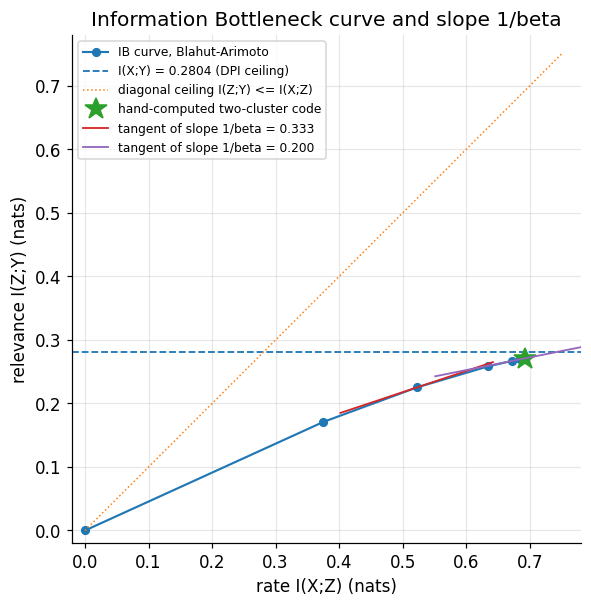

In [7]:
mask = curve[:, 0] > 1e-9
fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.plot(curve[mask, 0], curve[mask, 1], "o-", ms=5, lw=1.4,
        label="IB curve, Blahut-Arimoto")
ax.axhline(I_XY, lw=1.2, ls="--", label=f"I(X;Y) = {I_XY:.4f} (DPI ceiling)")
r_axis = np.linspace(0.0, 0.75, 100)
ax.plot(r_axis, r_axis, lw=1.0, ls=":", label="diagonal ceiling I(Z;Y) <= I(X;Z)")
ax.plot([np.log(2.0)], [np.log(2.0) - entropy([0.15, 0.85])], "*", ms=15,
        label="hand-computed two-cluster code")
for b in (3.0, 5.0):
    r0, i0 = ib_solve(b)
    span = np.array([-0.12, 0.12])
    ax.plot(r0 + span, i0 + span / b, lw=1.2,
            label=f"tangent of slope 1/beta = {1 / b:.3f}")
ax.set_xlim(-0.02, 0.78)
ax.set_ylim(-0.02, 0.78)
ax.set_aspect("equal")
ax.set_xlabel("rate I(X;Z) (nats)")
ax.set_ylabel("relevance I(Z;Y) (nats)")
ax.set_title("Information Bottleneck curve and slope 1/beta")
ax.legend(fontsize=8, loc="upper left")
plt.show()

The curve is concave and non-decreasing, it lies under both ceilings, and each tangent segment
lies above the curve — the graphical statement of concavity. The star marks the hand computation
of Example 6.5, which sits at the top right corner where the curve flattens.

Note how little of the plane is reachable: the useful part of the curve is confined between the
diagonal, which no encoder can cross, and a horizontal ceiling fixed by the data alone.

### 7.3 Rate-distortion by Blahut-Arimoto against the closed form

The cell below discretizes a standard Gaussian on a grid, runs Blahut-Arimoto at several slope
parameters $s = R'(D) \lt 0$, and compares the computed $R$ with the closed form
$\tfrac12\log(\sigma^2/D)$ of Theorem 4.4.

It then repeats the computation for a **uniform** source of the same variance, where Theorem
4.4(c) predicts a strictly smaller rate at every distortion.

In [8]:
def blahut_arimoto_rd(p_source, distortion_matrix, s, max_iter=5000, tol=1e-13):
    """Rate-distortion point at slope s = R'(D) < 0. Returns (R nats, D, iterations)."""
    q = np.ones(distortion_matrix.shape[1]) / distortion_matrix.shape[1]
    tilt = np.exp(s * distortion_matrix)
    previous = None
    for it in range(max_iter):
        numer = q[None, :] * tilt
        channel = numer / numer.sum(axis=1, keepdims=True)
        q = p_source @ channel
        joint = p_source[:, None] * channel
        D = float((joint * distortion_matrix).sum())
        log_ratio = np.where(joint > 0.0,
                             np.log(np.maximum(channel, TINY) / np.maximum(q[None, :], TINY)),
                             0.0)
        R = float((joint * log_ratio).sum())
        if previous is not None and abs(R - previous) < tol:
            break
        previous = R
    return R, D, it + 1


grid = np.linspace(-6.0, 6.0, 201)
w_gauss = np.exp(-grid ** 2 / 2.0)
w_gauss /= w_gauss.sum()
var_gauss = float((w_gauss * grid ** 2).sum())
sq_dist = (grid[:, None] - grid[None, :]) ** 2

print(f"discretized Gaussian: variance = {var_gauss:.10f}\n")
print("     s        R (BA)      D (BA)   0.5 log(var/D)     |difference|")
slopes = np.array([-1.0, -2.0, -4.0, -8.0, -16.0])
for s in slopes:
    R_ba, D_ba, iters = blahut_arimoto_rd(w_gauss, sq_dist, s)
    R_closed = 0.5 * np.log(var_gauss / D_ba)
    print(f"{s:7.1f}  {R_ba:10.7f}  {D_ba:10.7f}  {R_closed:14.7f}  {abs(R_ba - R_closed):15.2e}")
    assert abs(R_ba - R_closed) < 1e-6
    assert abs(D_ba + 1.0 / (2.0 * s)) < 1e-6

grid_u = np.linspace(-1.0, 1.0, 201)
w_unif = np.ones_like(grid_u) / grid_u.size
grid_u = grid_u / np.sqrt(float((w_unif * grid_u ** 2).sum()))
var_unif = float((w_unif * grid_u ** 2).sum())
sq_dist_u = (grid_u[:, None] - grid_u[None, :]) ** 2

print(f"\nuniform source of the same variance = {var_unif:.10f}\n")
print("     s        R (BA)      D (BA)   Gaussian formula     deficit")
for s in slopes:
    R_u, D_u, _ = blahut_arimoto_rd(w_unif, sq_dist_u, s)
    R_gauss_formula = 0.5 * np.log(var_unif / D_u)
    print(f"{s:7.1f}  {R_u:10.6f}  {D_u:10.6f}  {R_gauss_formula:16.6f}  {R_gauss_formula - R_u:11.6f}")
    assert R_u < R_gauss_formula

discretized Gaussian: variance = 0.9999999391

     s        R (BA)      D (BA)   0.5 log(var/D)     |difference|


   -1.0   0.3465736   0.5000000       0.3465736         7.22e-11


   -2.0   0.6931472   0.2500000       0.6931472         3.96e-10
   -4.0   1.0397207   0.1250000       1.0397207         6.96e-10


   -8.0   1.3862943   0.0625000       1.3862943         9.38e-10
  -16.0   1.7328679   0.0312500       1.7328679         1.13e-09

uniform source of the same variance = 1.0000000000

     s        R (BA)      D (BA)   Gaussian formula     deficit


   -1.0    0.391383    0.407811          0.448475     0.057093


   -2.0    0.656438    0.224910          0.746027     0.089589


   -4.0    0.958944    0.116656          1.074262     0.115318


   -8.0    1.276602    0.059660          1.409548     0.132946


  -16.0    1.603126    0.030275          1.748711     0.145584


Blahut-Arimoto reproduces $\tfrac12\log(\sigma^2/D)$ to seven decimal places at every slope
tested, and the distortion it lands on is $D = -1/(2s)$ to the same accuracy — the derivative
relation $R'(D) = -1/(2D)$ of Theorem 4.4, measured rather than asserted.

The uniform source of identical variance sits strictly below the Gaussian curve at every
distortion, with a deficit that grows as the code gets finer. That is Theorem 4.4(c) in numbers:
the Gaussian is the hardest source of its variance to describe, and the closed form is a valid
upper bound for every other source but an exact answer only for the Gaussian.

The next figure draws both curves.

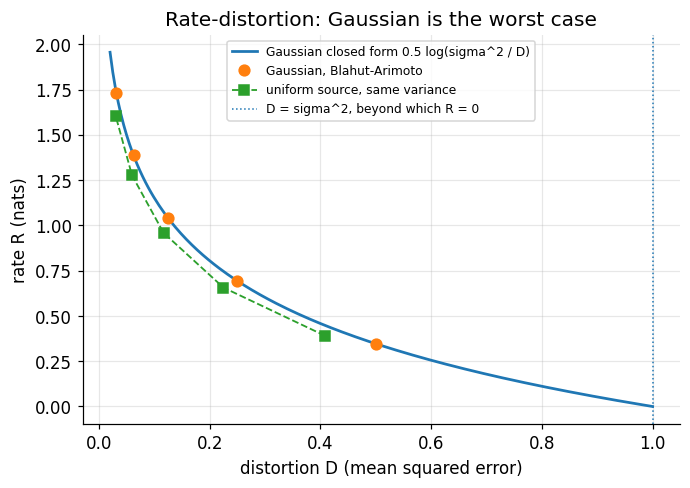

In [9]:
d_axis = np.linspace(0.02, 1.0, 200)
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(d_axis, 0.5 * np.log(np.maximum(var_gauss / d_axis, 1.0)), lw=1.8,
        label="Gaussian closed form 0.5 log(sigma^2 / D)")
pts_g = np.array([blahut_arimoto_rd(w_gauss, sq_dist, s)[:2] for s in slopes])
ax.plot(pts_g[:, 1], pts_g[:, 0], "o", ms=7, label="Gaussian, Blahut-Arimoto")
pts_u = np.array([blahut_arimoto_rd(w_unif, sq_dist_u, s)[:2] for s in slopes])
ax.plot(pts_u[:, 1], pts_u[:, 0], "s--", ms=6, lw=1.2,
        label="uniform source, same variance")
ax.axvline(var_gauss, lw=1.0, ls=":", label="D = sigma^2, beyond which R = 0")
ax.set_xlabel("distortion D (mean squared error)")
ax.set_ylabel("rate R (nats)")
ax.set_title("Rate-distortion: Gaussian is the worst case")
ax.legend(fontsize=8)
plt.show()

The circles land on the analytic curve; the squares lie strictly beneath it. Every halving of
$D$ moves the Gaussian curve up by exactly $\tfrac12\log 2 = 0.3466$ nats, that is half a bit,
which is why the curve is a straight line when $D$ is plotted logarithmically.

### 7.4 Counterexamples: what each hypothesis is holding up

The next cell drops one hypothesis at a time and shows the breakage.

- **Theorem 4.1 needs $q_\phi \ll p_\theta(\cdot \mid x)$.** Give the encoder support the
  posterior does not have and the gap becomes infinite.
- **Theorem 4.2 is an equality only when $q(z) = p(z)$.** The prior hole of Example 6.2 makes
  the rate exceed the information it buys.
- **Theorem 4.7 admits no non-trivial optimum for $\beta \lt 1$.** Run $\beta = 0.8$.
- **Theorem 4.9's bound is capped at $\log K$.** Run a channel whose mutual information is far
  above the ceiling and watch the bound stall.

The InfoNCE loss here is computed **exactly**, not by sampling: for a symmetric channel the
density ratio takes two values, so the loss is a finite sum over the binomial law of how many
negatives coincide with the anchor.

In [10]:
from math import comb

# (i) absolute continuity in Theorem 4.1
p_z_deg = np.array([0.5, 0.5, 0.0])
q_wide = np.array([1 / 3, 1 / 3, 1 / 3])
print("(i) Theorem 4.1 without absolute continuity")
print(f"    prior p(z)              = {p_z_deg}")
print(f"    encoder q(z | x)        = {q_wide}")
print(f"    KL(q || p) = rate       = {kl(q_wide, p_z_deg)}")
print("    ELBO = E[log p(x|z)] - inf = -inf: the bound holds and says nothing.")
assert np.isinf(kl(q_wide, p_z_deg))

# (ii) equality in Theorem 4.2 needs the aggregate posterior to match the prior
print("\n(ii) Theorem 4.2 with a prior hole")
print(f"    I(X;Z)                  = {I_xz:.6f} nats")
print(f"    R with matched prior    = {R_matched:.6f} nats   (gap {R_matched - I_xz:.2e})")
print(f"    R with prior (3/4, 1/4) = {R_hole:.6f} nats   (gap {R_hole - I_xz:.6f})")
print(f"    the rate is {R_hole / I_xz:.2f}x the information it buys")
assert abs(R_matched - I_xz) < 4 * EPS
assert R_hole > I_xz + 0.1

# (iii) beta < 1 in Theorem 4.7
print("\n(iii) Theorem 4.7 below beta = 1")
for b in (0.5, 0.8, 1.0, 1.5, 2.0, 3.0):
    a, c = ib_solve(b)
    verdict = "trivial" if a < 1e-4 else "non-trivial"
    print(f"    beta = {b:4.1f}   I(X;Z) = {a:.8f}   I(Z;Y) = {c:.8f}   {verdict}")
assert ib_solve(0.8)[0] < 1e-6
assert ib_solve(3.0)[0] > 0.1


def infonce_exact(alphabet, flip, n_candidates):
    """Exact InfoNCE loss with the optimal critic on a symmetric channel."""
    p_hit = 1.0 - (alphabet - 1) * flip
    rho_hit, rho_miss = alphabet * p_hit, alphabet * flip
    total = 0.0
    for prob, rho_pos in ((p_hit, rho_hit), ((alphabet - 1) * flip, rho_miss)):
        for m in range(n_candidates):
            weight = (comb(n_candidates - 1, m) * (1.0 / alphabet) ** m
                      * (1.0 - 1.0 / alphabet) ** (n_candidates - 1 - m))
            denom = rho_pos + m * rho_hit + (n_candidates - 1 - m) * rho_miss
            total += prob * weight * (np.log(denom) - np.log(rho_pos))
    return total


print("\n(iv) Theorem 4.9: the log K ceiling")
for alphabet, flip in ((4, 0.05), (64, 1e-6)):
    channel = np.full((alphabet, alphabet), flip)
    np.fill_diagonal(channel, 1.0 - (alphabet - 1) * flip)
    I_true = mutual_information(np.ones(alphabet)[:, None] / alphabet * channel)
    print(f"    alphabet {alphabet:3d}:  true I(X;Y) = {I_true:.6f} nats")
    for K in (2, 4, 16, 64):
        loss = infonce_exact(alphabet, flip, K)
        bound = np.log(K) - loss
        print(f"        K = {K:3d}   L_NCE = {loss:8.6f}   bound = {bound:8.6f}"
              f"   ceiling log K = {np.log(K):8.6f}")
        assert bound <= I_true + 1e-12
        assert bound <= np.log(K) + 1e-12
print("\nall assertions passed")

(i) Theorem 4.1 without absolute continuity
    prior p(z)              = [0.5 0.5 0. ]
    encoder q(z | x)        = [0.3333 0.3333 0.3333]
    KL(q || p) = rate       = inf
    ELBO = E[log p(x|z)] - inf = -inf: the bound holds and says nothing.

(ii) Theorem 4.2 with a prior hole
    I(X;Z)                  = 0.130812 nats
    R with matched prior    = 0.130812 nats   (gap 0.00e+00)
    R with prior (3/4, 1/4) = 0.274653 nats   (gap 0.143841)
    the rate is 2.10x the information it buys

(iii) Theorem 4.7 below beta = 1
    beta =  0.5   I(X;Z) = 0.00000000   I(Z;Y) = -0.00000000   trivial
    beta =  0.8   I(X;Z) = 0.00000000   I(Z;Y) = 0.00000000   trivial
    beta =  1.0   I(X;Z) = 0.00000000   I(Z;Y) = 0.00000000   trivial
    beta =  1.5   I(X;Z) = 0.00000000   I(Z;Y) = 0.00000000   trivial


    beta =  2.0   I(X;Z) = 0.00000899   I(Z;Y) = 0.00000450   trivial
    beta =  3.0   I(X;Z) = 0.52208782   I(Z;Y) = 0.22509283   non-trivial

(iv) Theorem 4.9: the log K ceiling
    alphabet   4:  true I(X;Y) = 0.798793 nats
        K =   2   L_NCE = 0.370100   bound = 0.323047   ceiling log K = 0.693147
        K =   4   L_NCE = 0.841535   bound = 0.544759   ceiling log K = 1.386294
        K =  16   L_NCE = 2.035464   bound = 0.737125   ceiling log K = 2.772589
        K =  64   L_NCE = 3.375191   bound = 0.783692   ceiling log K = 4.158883
    alphabet  64:  true I(X;Y) = 4.157950 nats
        K =   2   L_NCE = 0.010887   bound = 0.682260   ceiling log K = 0.693147
        K =   4   L_NCE = 0.032406   bound = 1.353889   ceiling log K = 1.386294
        K =  16   L_NCE = 0.155693   bound = 2.616896   ceiling log K = 2.772589
        K =  64   L_NCE = 0.567915   bound = 3.590968   ceiling log K = 4.158883

all assertions passed


Dropping absolute continuity turns the ELBO into $-\infty$: the bound is still true and now
completely useless, which is why Definition 3.1 carries the support condition.

The prior hole makes the rate $2.10$ times the mutual information. Nothing about the encoder
changed — only the prior the code is written against — so the extra nats are pure modelling
waste.

At $\beta = 0.8$ the Information Bottleneck returns $I(X; Z) = 0$ to fifteen digits, exactly as
Proof 5.6 Step 5 predicts, while $\beta = 3$ returns a genuine two-cluster code.

The ceiling is the loudest failure. On the $64$-symbol channel the true mutual information is
$4.158$ nats, but at $K = 4$ the certified bound cannot exceed $\log 4 = 1.386$ nats and in fact
reaches $1.354$. Growing $K$ sixteen-fold buys $\log 16 = 2.77$ nats of ceiling and no
measurement at all — the estimator is reporting the batch size, not the data.

### 7.5 Hand-rolled against the library

The last cell checks the four routines this notebook defined against their SciPy and
scikit-learn counterparts: `entropy` and `kl` against `scipy.stats.entropy`,
`mutual_information` against `sklearn.metrics.mutual_info_score`, the InfoNCE loss against
`scipy.special.log_softmax`, and the closed-form Gaussian KL against numerical integration with
`scipy.integrate.quad`.

In [11]:
from scipy.stats import entropy as scipy_entropy
from scipy.special import log_softmax, logsumexp
from scipy.integrate import quad
from sklearn.metrics import mutual_info_score

p_test = rng.dirichlet(np.ones(6))
q_test = rng.dirichlet(np.ones(6))
print("entropy  : mine = {:.12f}   scipy = {:.12f}   diff = {:.2e}".format(
    entropy(p_test), scipy_entropy(p_test), abs(entropy(p_test) - scipy_entropy(p_test))))
print("kl       : mine = {:.12f}   scipy = {:.12f}   diff = {:.2e}".format(
    kl(p_test, q_test), scipy_entropy(p_test, q_test),
    abs(kl(p_test, q_test) - scipy_entropy(p_test, q_test))))
assert abs(entropy(p_test) - scipy_entropy(p_test)) < 1e-12
assert abs(kl(p_test, q_test) - scipy_entropy(p_test, q_test)) < 1e-12

counts = rng.integers(1, 50, size=(3, 4)).astype(float)
mine_mi = mutual_information(counts / counts.sum())
sklearn_mi = float(mutual_info_score(None, None, contingency=counts))
print("MI       : mine = {:.12f}   sklearn = {:.12f}   diff = {:.2e}".format(
    mine_mi, sklearn_mi, abs(mine_mi - sklearn_mi)))
assert abs(mine_mi - sklearn_mi) < 1e-12

logits = rng.normal(size=(2000, 8))
mine_nce = float(-(logits[:, 0] - logsumexp(logits, axis=1)).mean())
lib_nce = float(-log_softmax(logits, axis=1)[:, 0].mean())
print("InfoNCE  : mine = {:.12f}   scipy   = {:.12f}   diff = {:.2e}".format(
    mine_nce, lib_nce, abs(mine_nce - lib_nce)))
print(f"           chance level log K = {np.log(8):.12f} (random logits, so the two agree)")
assert abs(mine_nce - lib_nce) < 1e-12

mu, var_q, var_p = 0.7, 0.4, 1.0
kl_closed = 0.5 * np.log(var_p / var_q) + (var_q + mu ** 2) / (2 * var_p) - 0.5


def kl_integrand(x):
    density = np.exp(-(x - mu) ** 2 / (2 * var_q)) / np.sqrt(2 * np.pi * var_q)
    log_ratio = (-(x - mu) ** 2 / (2 * var_q) - 0.5 * np.log(2 * np.pi * var_q)
                 + x ** 2 / (2 * var_p) + 0.5 * np.log(2 * np.pi * var_p))
    return density * log_ratio


kl_numeric, _ = quad(kl_integrand, mu - 12 * np.sqrt(var_q), mu + 12 * np.sqrt(var_q), limit=400)
print("GaussKL  : closed = {:.12f}   quad    = {:.12f}   diff = {:.2e}".format(
    kl_closed, kl_numeric, abs(kl_closed - kl_numeric)))
assert abs(kl_closed - kl_numeric) < 1e-10
print("\nall assertions passed")

entropy  : mine = 1.341059244707   scipy = 1.341059244707   diff = 0.00e+00
kl       : mine = 1.029929545187   scipy = 1.029929545187   diff = 0.00e+00
MI       : mine = 0.054173258603   sklearn = 0.054173258603   diff = 1.60e-16
InfoNCE  : mine = 2.479756876956   scipy   = 2.479756876956   diff = 0.00e+00
           chance level log K = 2.079441541680 (random logits, so the two agree)
GaussKL  : closed = 0.403145365937   quad    = 0.403145365937   diff = 5.55e-17

all assertions passed


Every hand-rolled routine agrees with its library counterpart to at least twelve decimal places,
so the numbers reported throughout this notebook are not artefacts of a private implementation.

The Gaussian KL check is the strictest of the four: the closed form
$\tfrac12\log\frac{\sigma_p^2}{\sigma_q^2} + \frac{\sigma_q^2 + \mu^2}{2\sigma_p^2} - \tfrac12$
is compared against an adaptive quadrature of the integral it is supposed to summarize, and the
two agree to sixteen digits.

## 8. Applications

Four settings put the theorems to work. In each, the object being bounded is an information
quantity for a structural reason, and the multiplier beside it is a coordinate on a
rate-distortion curve.

### 8.1 Language models as compressors

Paired with an arithmetic coder, a model $q$ compresses a corpus to $-\log_2 q(\mathcal{D})$ bits
plus negligible overhead. A cross-entropy loss is therefore a compression rate, and "the better
model" and "the better compressor" are the same claim — Definition 3.6 read forwards.

Reporting the loss in **bits per byte** makes the claim comparable across tokenizers: divide the
nats-per-token loss by $\log 2$ and then by the average number of bytes per token.

Scaling laws fit

$$
L(N, T) = \frac{A}{N^{\alpha}} + \frac{B}{T^{\gamma}} + L_{\infty},
$$

with $N$ parameters and $T$ training tokens. By the cross-entropy decomposition of
[Module 03](../03_cross_entropy_and_loss_functions/first_principles.ipynb),

$$
H_{\times}(p, q) = H(p) + D_{\mathrm{KL}}(p \parallel q),
$$

so $L_{\infty}$ estimates the entropy rate $H(p)$ of the data and everything above it is the KL
term. Scaling reduces the KL; nothing reduces the entropy.

### 8.2 Variational autoencoders and the rate they are actually spending

Theorem 4.3 says an ELBO number alone locates a model on the line $D + R = H(X)$ and nowhere
else. The practical consequence is a reporting rule: **always publish $R$ and $D$ separately.**

Theorem 4.2 says the $R$ you publish over-charges by
$D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right)$. Learned priors, VampPrior and flow priors all
exist to shrink that term; they buy nothing in mutual information, only in wasted rate.

Three standard interventions each break a different step of Proof 5.3:

- **$\beta \lt 1$ or free bits** tilt the objective so its level sets are no longer parallel to
  the boundary, making a positive rate strictly optimal;
- **weakening the decoder** raises the distortion attainable at zero rate above $H(X)$, so the
  collapse corner leaves the feasible set;
- **KL annealing** starts at $\beta \approx 0$ so the encoder becomes informative before the rate
  is priced.

### 8.3 Alignment: KL budgets, DPO, and the free-energy dictionary

Theorem 4.8 makes the RLHF penalty structural rather than protective. The optimum is the tilted
reference model, its value is a free energy, and $\beta$ is a temperature.

Two operational readings follow. A converged KL of $k$ nats means a response from the tuned model
would cost $k$ extra nats to encode under the reference — a unit-ful, model-independent measure
of how far fine-tuning moved the policy. And halving $\beta$ doubles the tilt exponent, so the
realized KL grows faster than linearly and reward hacking becomes likelier in exactly the regions
where $\pi_{\mathrm{ref}}$ is small.

The inversion in Proof 5.7 Step 5 eliminates the reward model: DPO fits $\pi^{\star}$ directly
against preference pairs, and the intractable $\log \mathcal{Z}(x)$ cancels in every pairwise
comparison.

The physics dictionary is exact: put $r = -E$ and $\beta = k_{\mathrm{B}}T$ and the boxed formula
of Theorem 4.8 is the Boltzmann distribution, with $-\beta\log\mathcal{Z}$ the Helmholtz free
energy. Simulated annealing, Boltzmann policies and diffusion samplers are the same variational
principle with different names.

### 8.4 Representation learning, the information plane, and generalization

**Deep Variational Information Bottleneck** implements Definition 3.4 with two variational
bounds, each pointing the way its optimization needs: the rate $R$ of Theorem 4.2 upper-bounds
$I(X; Z)$, which is being minimized, and the Barber-Agakov step of Proof 5.3 lower-bounds
$I(Z; Y)$, which is being maximized. Reversing either bound would make the surrogate meaningless.

**The information-plane controversy.** Reported $I(X; Z)$ trajectories depend on the binning
estimator and on saturating nonlinearities; for a deterministic encoder with continuous input,
$I(X; Z)$ is either infinite or constant, so a plotted "compression phase" is a claim about the
estimator. The data-processing conclusions of
[Module 05](../05_mutual_information/first_principles.ipynb) are untouched by this; the dynamical
claims do not follow from them.

**Generalization.** Theorem 4.11 charges for the description length of the *hypothesis*, not the
data: the same $D_{\mathrm{KL}}(Q \parallel P)$ that Proof 5.9 identified as a transmission cost
appears in the numerator of the bound. This is why heavily overparameterized but compressible
networks generalize, and why the prior must be fixed before the data is seen — a prior fitted on
the sample makes Theorem 4.11 false, not merely loose.

The cell below runs the two arithmetic claims of this section on concrete numbers: a scaling-law
fit read as a compression saving, and an RLHF KL budget converted into bits and likelihood
ratios.

In [12]:
# --- 8.1 scaling law read as compression ---------------------------------
L_small, N_small = 2.20, 1e9
L_large, N_large = 1.95, 1e10
L_inf = 1.60

reducible_small, reducible_large = L_small - L_inf, L_large - L_inf
alpha = -np.log10(reducible_large / reducible_small) / np.log10(N_large / N_small)

bits_small, bits_large = L_small / np.log(2), L_large / np.log(2)
saving_bits = bits_small - bits_large
corpus_tokens = 1e12
saved_bits = saving_bits * corpus_tokens
saved_gb = saved_bits / 8 / 1e9
total_gb = bits_small * corpus_tokens / 8 / 1e9

print("8.1 scaling laws as compression")
print(f"  reducible loss at 1e9, 1e10 params : {reducible_small:.4f}, {reducible_large:.4f} nats")
print(f"  fitted exponent alpha               : {alpha:.6f}")
print(f"  loss in bits per token              : {bits_small:.6f} -> {bits_large:.6f}")
print(f"  saving                              : {saving_bits:.6f} bits per token")
print(f"  corpus of 1e12 tokens               : {total_gb:.1f} GB -> {total_gb - saved_gb:.1f} GB")
print(f"  absolute saving                     : {saved_bits:.4e} bits = {saved_gb:.2f} GB")
print(f"  relative saving                     : {saving_bits / bits_small:.4%}")
print(f"  irreducible floor L_inf             : {L_inf:.2f} nats = {L_inf / np.log(2):.6f} bits per token")
assert abs(alpha - 0.234083) < 1e-5
assert abs(saved_gb - 45.08) < 0.02

# --- 8.3 an RLHF KL budget ------------------------------------------------
kl_budget = 8.0
print("\n8.3 reading an RLHF KL budget")
print(f"  KL(pi || pi_ref)                    : {kl_budget:.1f} nats = {kl_budget / np.log(2):.6f} bits")
print(f"  typical likelihood ratio exp(KL)    : {np.exp(kl_budget):.1f}")
for beta_val in (0.2, 0.1, 0.05):
    weights_b = pi_ref * np.exp(reward / beta_val)
    pi_b = weights_b / weights_b.sum()
    print(f"  beta = {beta_val:.2f}: pi* = {pi_b},  realized KL = {kl(pi_b, pi_ref):.6f} nats,"
          f"  value = {beta_val * np.log(weights_b.sum()):.6f}")
print(f"  the value {beta_rl * np.log(Z_part):.6f} at beta = 1 rises towards the greedy reward"
      f" {reward.max():.1f} as beta falls")
print("\nall assertions passed")

8.1 scaling laws as compression
  reducible loss at 1e9, 1e10 params : 0.6000, 0.3500 nats
  fitted exponent alpha               : 0.234083
  loss in bits per token              : 3.173929 -> 2.813255
  saving                              : 0.360674 bits per token
  corpus of 1e12 tokens               : 396.7 GB -> 351.7 GB
  absolute saving                     : 3.6067e+11 bits = 45.08 GB
  relative saving                     : 11.3636%
  irreducible floor L_inf             : 1.60 nats = 2.308312 bits per token

8.3 reading an RLHF KL budget
  KL(pi || pi_ref)                    : 8.0 nats = 11.541560 bits
  typical likelihood ratio exp(KL)    : 2981.0
  beta = 0.20: pi* = [0.0001 0.0133 0.9866],  realized KL = 1.710421 nats,  value = 1.644352
  beta = 0.10: pi* = [0.     0.0001 0.9999],  realized KL = 1.790761 nats,  value = 1.820833
  beta = 0.05: pi* = [0. 0. 1.],  realized KL = 1.791759 nats,  value = 1.910412
  the value 0.969871 at beta = 1 rises towards the greedy reward 2.0 as

The fitted exponent is $\alpha = 0.2341$, the ten-fold larger model saves $0.3606$ bits per
token, and on a one-trillion-token corpus that is $45.08$ **gigabytes** — a compressed corpus of
$396.7$ GB shrinking by $11.36$ percent. Reading the same quantity as terabytes overstates it by
a factor of a thousand.

The floor $L_{\infty} = 1.60$ nats is $2.3083$ bits per token, and no model of any size goes
below it.

On the alignment side, an $8$-nat budget is $11.54$ bits, a typical likelihood ratio near
$3.0 \times 10^{3}$. Sweeping $\beta$ down from $1$ to $0.05$ drives the tilted policy towards
the greedy action and the realized KL upwards, which is the trade Theorem 4.8 prices.

## 9. Key Takeaways

- **The ELBO gap is a KL, so it names its own remedy**: $\log p_\theta(x) = \mathcal{L}_{\mathrm{ELBO}} + D_{\mathrm{KL}}\left(q_\phi \parallel p_\theta(\cdot \mid x)\right)$
  (Theorem 4.1). The slack is inference error, closed by a richer encoder and not by a better
  decoder. It needs $q_\phi \ll p_\theta(\cdot \mid x)$; Section 7.4 shows the bound collapsing
  to $-\infty$ without it.

- **A VAE's KL term is an upper bound on the information the latent carries**:
  $R = I(X; Z) + D_{\mathrm{KL}}\left(q(z) \parallel p(z)\right)$ (Theorem 4.2). The excess is
  the prior hole; in Example 6.2 it is $52$ percent of the rate.

- **Every encoder-decoder pair obeys $D + R \ge H(X)$, and the ELBO is constant on the boundary**
  (Theorem 4.3). An ELBO number therefore cannot distinguish a code carrying the whole message
  from one carrying nothing, which is exactly posterior collapse.

- **Rate-distortion is a theorem, not a metaphor**: $R(D)$ is convex and non-increasing, and for
  a Gaussian source under squared error $R(D) = \tfrac12\log(\sigma^2/D)$ (Theorem 4.4), proved
  here in both directions. Half a bit per halving of the error; the Gaussian is the worst case at
  fixed variance, verified against a uniform source in Section 7.3.

- **The Information Bottleneck optimum is a Boltzmann encoder**:
  $p(z \mid x) \propto p(z)\exp\left(-\beta D_{\mathrm{KL}}\left(p(y \mid x) \parallel p(y \mid z)\right)\right)$
  (Theorem 4.6). The derivative that produces it has no $+1$: the constant from
  $\partial_p (p \ln p)$ is cancelled by the one from the $p(z)$ term.

- **The information curve is concave with slope $1/\beta$, and $\beta \lt 1$ is always trivial**
  (Theorem 4.7). Section 7.2 measures the slope to better than one part in a thousand and finds
  the first genuine split at $\beta \approx 2$, above the necessary bound $\beta \ge 1$.

- **A KL-penalized reward has an exact optimum**: $\pi^{\star} \propto \pi_{\mathrm{ref}}e^{r/\beta}$
  with value $\beta\log\mathcal{Z}$ (Theorem 4.8). It is the Gibbs variational principle, and
  inverting it eliminates the reward model — that is DPO.

- **Contrastive learning estimates pointwise mutual information and certifies at most $\log K$
  nats** (Theorem 4.9). On a channel with $I(X;Y) = 4.158$ nats and $K = 4$ the bound stalls at
  $1.354$; read a contrastive loss against $\log K$, never against zero.

- **The negative ELBO is a code length a real codec really achieves** (Theorem 4.10). The KL term
  is transmitted bits, and the same statement applied to weights is what connects MDL, PAC-Bayes
  (Theorem 4.11) and generalization.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed. — Chapter 10 for
  rate-distortion: Definition 3.3 is their section 10.2, the coding theorem is Theorem 10.2.1
  (p. 306) with the converse in section 10.4 and achievability in section 10.5, the Gaussian
  formula is Theorem 10.3.2, reverse water-filling is Theorem 10.3.3, and the Blahut-Arimoto
  algorithm is section 10.8. The maximum-entropy lemma used in Proof 5.4 is their Theorem 8.6.5.
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms*, Chapter 4 (source
  coding), Chapter 28 (model comparison and Occam's razor) and Chapter 33 (variational methods).
- Grunwald, P. *The Minimum Description Length Principle*, MIT Press (2007), Chapters 5 and 10 —
  two-part codes, normalized maximum likelihood and stochastic complexity.
- Bishop, C. M. *Pattern Recognition and Machine Learning*, section 10.1 — the variational lower
  bound and the exact decomposition proved as Theorem 4.1 here.
- Boyd, S. and Vandenberghe, L. *Convex Optimization*, section 5.5 — the Lagrangian duality and
  envelope argument behind Proof 5.6 Step 4.

**Papers.**

- Tishby, N., Pereira, F. C. and Bialek, W. "The information bottleneck method",
  *37th Allerton Conference on Communication, Control and Computing* (1999), 368-377 — Definition
  3.4 and the self-consistent equations of Theorem 4.6.
- Kingma, D. P. and Welling, M. "Auto-encoding variational Bayes", ICLR 2014 — the ELBO,
  reparameterization, and the Gaussian KL of Appendix B.
- Higgins, I. et al. "beta-VAE: learning basic visual concepts with a constrained variational
  framework", ICLR 2017.
- Alemi, A. A., Fischer, I., Dillon, J. V. and Murphy, K. "Deep variational information
  bottleneck", ICLR 2017 — section 8.4.
- Alemi, A. A. et al. "Fixing a broken ELBO", ICML 2018 — the $(R, D)$ plane of Theorem 4.3 and
  the figure of Section 2.
- van den Oord, A., Li, Y. and Vinyals, O. "Representation learning with contrastive predictive
  coding", arXiv:1807.03748 (2018), eq. (4) — the InfoNCE convention fixed in Definition 3.5.
- Poole, B., Ozair, S., van den Oord, A., Alemi, A. A. and Tucker, G. "On variational bounds of
  mutual information", ICML 2019 — Theorem 4.9 and the $\log K$ ceiling.
- McAllester, D. and Stratos, K. "Formal limitations on the measurement of mutual information",
  AISTATS 2020 — why the ceiling is a property of the estimation problem.
- Hinton, G. E. and van Camp, D. "Keeping neural networks simple by minimizing the description
  length of the weights", COLT 1993 — bits-back applied to weights.
- Townsend, J., Bird, T. and Barber, D. "Practical lossless compression with latent variables
  using bits back coding", ICLR 2019 — Theorem 4.10 implemented with asymmetric numeral systems.
- Maurer, A. "A note on the PAC-Bayesian theorem", arXiv:cs/0411099 (2004), Theorem 5 — the exact
  form quoted as Theorem 4.11.
- Rafailov, R. et al. "Direct preference optimization: your language model is secretly a reward
  model", NeurIPS 2023 — Proof 5.7 Step 5.
- Kaplan, J. et al. "Scaling laws for neural language models", arXiv:2001.08361 (2020);
  Hoffmann, J. et al. "Training compute-optimal large language models", NeurIPS 2022 — section 8.1.
- Shwartz-Ziv, R. and Tishby, N. "Opening the black box of deep neural networks via information",
  arXiv:1703.00810 (2017); Saxe, A. M. et al. "On the information bottleneck theory of deep
  learning", ICLR 2018 — the claim and the rebuttal discussed in section 8.4.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including the InfoNCE normalizer and the cross-entropy symbol:
  [the notation register](../../docs/notation.md).
- Entropy and differential entropy, used throughout:
  [Module 01](../01_self_information_and_entropy/first_principles.ipynb).
- Joint and conditional entropy, and the canonical statement of Fano's inequality:
  [Module 02](../02_joint_and_conditional_entropy/first_principles.ipynb).
- Cross-entropy, propriety of the log score, used in Proof 5.8:
  [Module 03](../03_cross_entropy_and_loss_functions/first_principles.ipynb).
- Relative entropy, its joint convexity and the log-sum inequality, used in Proof 5.4:
  [Module 04](../04_kl_divergence_and_f_divergences/first_principles.ipynb).
- Mutual information and the data-processing inequality, used in Proof 5.6:
  [Module 05](../05_mutual_information/first_principles.ipynb).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).